# Term Paper 2 - Expectations about Macroeconomic and Financial Variables

Candidate numbers: 154, 184, 197

### Initial Setup - Modules, Display options, Data Path

In [1]:
# Modules
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
# Scikit-learn modules for regression, classification and evaluation
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# For correlation tables
from IPython.display import display, HTML

# Set display options for better readability
pd.set_option('display.max_columns', 50)

# Set plot style for consistent and visually appealing graphs
plt.style.use('seaborn-v0_8-whitegrid')

# Define the path to the data directory
DATA_PATH = './data'

## Part 1 - Data Preprocessing (SCE)

The individual-level SCE data is loaded, merged across all survey years, and cleaned in several steps: variables recorded only at the first interview are forward-filled, 2025 observations are dropped, missing values are removed for all analysis variables, and outliers are trimmed at the 1st and 99th percentiles for the four target expectations variables. Finally, three binary optimism indicators are created for use in Part 6.

### 1.1 - Load SCE and Report Initial Sample Characteristics

In [2]:
def load_sce(DATA_PATH: str):
    """
    Load and concatenate SCE CSV files, keeping only relevant columns and parsing dates.

    Parameters
    ----------
    DATA_PATH : str
        Path to the directory containing the SCE CSV files.

    Returns
    -------
    tuple
        (COLS_FIRST_WAVE, COLS_META, COLS_EXPECTATIONS, COLS_INDIVIDUAL,
        ANALYSIS_COLS, ALL_COLS, sce) where sce is the concatenated DataFrame
        of all SCE survey waves.
    """
    # Define columns to read from the CSV files
        # Columns with variables only reported in the first wave of the survey
    COLS_FIRST_WAVE = ['owner','num_lit_q1_correct', 'num_lit_q2_correct', 'num_lit_q3_correct', 'num_lit_q5_correct', 'num_lit_q6_correct']
        # Columns with metadata
    COLS_META = ['userid', 'wid', 'date', 'tenure']
        # Columns with expectation-variables (Targets for modelling later)
    COLS_EXPECTATIONS = ['infl_1y', 'house_price_change', 'prob_unrate_up', 'prob_stocks_up']
        # Columns with individual characteristics
    COLS_INDIVIDUAL = ['female', 'hispanic', 'black', 'educ', 'hh_inc_bin_rank', 'working', 'couple', 'num_kids', 'age_init']
        # Combine all columns for analysis
    ANALYSIS_COLS = COLS_FIRST_WAVE + COLS_EXPECTATIONS + COLS_INDIVIDUAL
        # Combine all columns to read from the CSV files
    ALL_COLS  = COLS_META + ANALYSIS_COLS

    # Read and concatenate all CSV files, keeping only the relevant columns and parsing dates
    files = sorted(glob.glob(f'{DATA_PATH}/sce_extract_*.csv'))
    sce = pd.concat(
        (pd.read_csv(file, usecols=ALL_COLS, parse_dates=['date']) for file in files),
        ignore_index=True
    )
    return COLS_FIRST_WAVE, COLS_META, COLS_EXPECTATIONS, COLS_INDIVIDUAL, ANALYSIS_COLS, ALL_COLS, sce

In [3]:
# Load SCE data and store Columns in variables for later use
COLS_FIRST_WAVE, COLS_META, COLS_EXPECTATIONS, COLS_INDIVIDUAL, ANALYSIS_COLS, ALL_COLS, sce = load_sce(DATA_PATH)

# Number of observations, individuals, and survey waves in the initial dataset
n_obs_init   = len(sce)
n_ind_init   = sce['userid'].nunique()
n_waves_init = sce['wid'].nunique()

# Date range of the initial dataset
first_date_init = sce['date'].min().date()
last_date_init  = sce['date'].max().date()

# Print initial data summary
print("=== Initial sample ===")
print(f"  Observations : {n_obs_init:,}")
print(f"  Individuals  : {n_ind_init:,}")
print(f"  Survey waves : {n_waves_init}")
print(f"  Date range   : {first_date_init} → {last_date_init}")

=== Initial sample ===
  Observations : 180,268
  Individuals  : 23,886
  Survey waves : 143
  Date range   : 2013-06-01 → 2025-05-01


The individual-level features were selected based on two criteria: economic relevance as predictors of expectations, and data availability. Several variables were excluded due to a high share of missing values (20% or more), which would have substantially reduced the sample size: num_lit_q8_correct, num_lit_q9_correct, take_fin_risk, health, and self_employed. The survey sampling weight was dropped since not all scikit-learn estimators support sample weights.
Variables asked only at the first interview (owner, age_init, and the numerical literacy indicators) are forward-filled within each individual so that later waves carry the value from the first wave. Other expectation-related variables (e.g. infl_3y, prob_irate_up) are excluded as predictors, since they would not be available to a policymaker trying to forecast expectations in real time.

age_init was recorded at first interview, but carried forward prior to our analysis, hence why it's not in COLS_FIRST_WAVE. 

### 1.2 - Forward-Fill First Wave Variables Within Each Individual

In [4]:
# Step 2 - Forward-fill within each individual (only fills NaNs after the first observed value)
sce[COLS_FIRST_WAVE] = (
    sce.groupby('userid')[COLS_FIRST_WAVE].ffill()
)

### 1.3 - Drop 2025 Observations to Avoid Trump-Volatility

In [5]:
# Step 3 - Drop observations from 2025 due to Trump-volatility
mask_2025 = sce['date'].dt.year == 2025
n_dropped_2025 = mask_2025.sum()
sce = sce[~mask_2025].copy()
print(f"Step 3 — Dropped {n_dropped_2025:,} observations from 2025")

Step 3 — Dropped 4,167 observations from 2025


### 1.4 - Drop Missing Values in Analysis Columns

In [6]:
# Step 4 - Drop observations with missing values in the analysis columns
n_before = len(sce)
sce = sce.dropna(subset=ANALYSIS_COLS).copy()
print(f"Step 4 — Dropped {n_before - len(sce):,} observations with missing values")

Step 4 — Dropped 16,966 observations with missing values


### 1.5 - Trim outliers in Expectations Columns (Targets) at 1st and 99th Percentiles

In [7]:
# Step 5 - Trim outliers in expectation columns by capping values at the 1st and 99th percentiles
def trim_outliers(df, cols):
    """
    Drop rows where any specified column falls outside the 1st-99th percentile range.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame to filter.
    cols : list[str]
        Column names in which to trim outliers.

    Returns
    -------
    pd.DataFrame
        DataFrame with outlier rows removed for each specified column.
    """
    # Find percentiles for each column
    percentiles = {col: (df[col].quantile(0.01), df[col].quantile(0.99)) for col in cols}
    
    # Store the original number of observations before trimming
    obs_dropped = 0
    # Trim outliers for each column
    for col in cols:
        p1, p99 = percentiles[col]
        before = len(df)
        df = df[(df[col] > p1) & (df[col] < p99)]
        obs_dropped += before - len(df)
        print(f'  Trimmed {before - len(df):,} observations in column "{col}" outside [{p1:.2f}, {p99:.2f}]')

    # Final summary of outliers dropped
    print('-'*50)
    print(f"Step 5 — Dropped {obs_dropped:,} observations as outliers")
    
    return df

In [8]:
# Trim outliers in expectation columns
sce = trim_outliers(sce, COLS_EXPECTATIONS)

  Trimmed 3,400 observations in column "infl_1y" outside [-30.00, 60.00]
  Trimmed 3,790 observations in column "house_price_change" outside [-20.00, 50.00]
  Trimmed 4,034 observations in column "prob_unrate_up" outside [0.00, 100.00]
  Trimmed 2,394 observations in column "prob_stocks_up" outside [0.00, 95.00]
--------------------------------------------------
Step 5 — Dropped 13,618 observations as outliers


For prob_unrate_up, the 1st percentile is 0 and the 99th percentile is 100. Since the trimming condition is strictly > P1 and < P99, observations with values exactly equal to 0 or 100 are dropped. These are respondents who are completely certain about the direction of unemployment, which are valid responses rather than data errors - however, we follow the assignment instructions and apply the same rule to all four variables.
For prob_stocks_up, P99 = 95, meaning the top 1% of responses (above 95%) are removed as extreme outliers.

### 1.6 - Create Optimism Indicators

In [9]:
# Step 6 - Create Optimism indicators
sce['optimist_unrate']      = (sce['prob_unrate_up'] < 50).astype(int)
sce['optimist_stocks']      = (sce['prob_stocks_up'] > 50).astype(int)
sce['optimist_house_price'] = (sce['house_price_change'] > 0).astype(int)

# Store optimism indicators in a list for later use
OPTIMISM_COLS = ['optimist_unrate', 'optimist_stocks', 'optimist_house_price']

# Update ALL_COLS to include the new optimism indicators
ALL_COLS += OPTIMISM_COLS

### End Part 1: Display Initial and Final Sample Information

In [10]:
# Data cleaning summary
summary = pd.DataFrame({
    'Sample'       : ['Initial', 'Final', 'Difference'],
    'Observations' : [n_obs_init, len(sce), len(sce) - n_obs_init],
    'Individuals'  : [n_ind_init, sce['userid'].nunique(), sce['userid'].nunique() - n_ind_init],
    'Survey waves' : [n_waves_init, sce['wid'].nunique(), sce['wid'].nunique() - n_waves_init],
    'First date'   : [first_date_init, sce['date'].min().date(), 'No Change'],
    'Last date'    : [last_date_init, sce['date'].max().date(), f'{(sce["date"].max().date() - last_date_init).days} days'],
})
display(summary)

,Sample,Observations,Individuals,Survey waves,First date,Last date
0,Initial,180268,23886,143,2013-06-01,2025-05-01
1,Final,145517,21783,139,2013-06-01,2024-12-31
2,Difference,-34751,-2103,-4,No Change,-121 days


After cleaning the data, we are left with $145{,}517$ observations - which is close to the target of ~$150{,}000$. In total, $34{,}751$ observations, $2{,}103$ individuals and $4$ survey waves were removed form the original data set. Final date was moved $121$ days earlier - after removing 2025 data due to Trump-volatility. 

## Part 2 - Data Preprocessing (Macro/Finance)

All macro and financial time series are downloaded and saved as CSV files in the "data" folder. **Yahoo Finance** data was downloaded programmatically using yfinance, while **FRED** data was downloaded manually from fred.stlouisfed.org. All series are resampled to monthly frequency. To avoid look-ahead bias, each series is shifted forward by one month so that a respondent interviewed in month $t$ only sees data available through the end of month $t−1$. For quarterly series (GDP, House Price Index), values are forward-filled within the quarter.

Additionally, we added two series not mentioned in the assignment - CBOE Volatility Index (VIX) and US 10-year treasury yield. 
- VIX captures uncertainty directly, which could be relevant for prob_stocks_up and general economic expectations.  
- The 10-year treasury yield as the long end of the yield curve embeds market participants' inflation and growth expectations, making it a good candidate for modelling infl_1y. 

Variables are included both in levels and as changes:

- Levels capture the current macroeconomic environment (e.g., high unemployment may anchor pessimism about future unemployment).
- 12-month changes capture recent momentum and surprises (e.g., a sharp rise in CPI may push inflation expectations higher regardless of the level).
- 1-month changes are computed for monthly series only and capture short-run surprises.
- VIX is kept only in levels since it is already a measure of reltive uncertainty. Percentage changes would be harder to interpret economically. 

For series expressed as index or price levels (CPI, House Price Index, Real GDP, USD Index, WTI Crude Oil, S&P 500), changes are expressed as percentage growth rates, since a one-unit absolute difference is not economically meaningful. For series already expressed in percentage terms (Federal Funds Rate, Unemployment Rate, 30-Year Mortgage Rate), changes are expressed as percentage-point differences, since a relative change (e.g. "the fed funds rate doubled") would be misleading when the level is near zero.
The final selection of which transformations to use as predictors is deferred to Parts 5 and 6, guided by the correlation analysis in Part 4.

In [11]:
# Reuseable function to load and process Yahoo Finance data
def load_yahoo(data_path: str) -> pd.DataFrame:
    """
    Load Yahoo Finance data from CSV files, resample to monthly frequency, and compute changes.

    Parameters
    ----------
    data_path : str
        Path to the directory containing the Yahoo Finance CSV files.

    Returns
    -------
    pd.DataFrame
        Monthly panel with price levels and 1-month / 12-month percentage changes
        for WTI crude oil and the S&P 500, shifted one month to avoid look-ahead bias.
    """
    # Define the mapping of column names to their corresponding CSV filenames
    files = {
        'wti_crude_oil': 'wti_crude_oil.csv',
        'sp500':         'sp500.csv',
    }
    # Initialize an empty list to store the monthly DataFrames
    monthly = []
    # Loop through each file, load the data, resample to monthly frequency, compute percentage changes, and store in the list
    for col, filename in files.items():
        df = pd.read_csv(f'{data_path}/{filename}', parse_dates=['date'], index_col='date')
        print(f'Loaded {col} with {len(df):,} observations from {df.index.min().date()} to {df.index.max().date()}')
        # Resample to monthly frequency using month-end as the anchor, take the last observation of each month, and compute percentage changes
        m = df.resample('ME').last()
        m[f'{col}_chg']     = m[col].pct_change()
        m[f'{col}_chg12m'] = m[col].pct_change(12)
        monthly.append(m.shift(1))

    # Concatenate all processed series
    out = pd.concat(monthly, axis=1)
    # Shift all series by one month to avoid look-ahead bias and sort by index
    out = out.shift(1).sort_index()
    # Limit date range to match the SCE data
    out = out[(out.index >= sce['date'].min()) & (out.index <= sce['date'].max())]

    return out

In [12]:
# Load Yahoo Finance data
yahoo = load_yahoo(DATA_PATH)

Loaded wti_crude_oil with 3,772 observations from 2010-01-04 to 2024-12-31
Loaded sp500 with 3,774 observations from 2010-01-04 to 2024-12-31


Yahoo Finance series are loaded and merged, with 1-month and 12-month change calculations performed, date range limited to SCE data, and observations shifted by a month.

In [13]:
# Reusable function to load and preprocess FRED data based on the configuration
def load_fred(data_path: str, config: dict) -> pd.DataFrame:
    """
    Load, resample, compute changes, and shift FRED series to monthly frequency.

    Parameters
    ----------
    data_path : str
        Path to the directory containing the FRED CSV files.
    config : dict
        Mapping of series name -> (filename, is_quarterly, chg_fn) where
        is_quarterly indicates whether the series is quarterly (bool) and
        chg_fn is one of "pct", "diff", or None.

    Returns
    -------
    pd.DataFrame
        Monthly panel of FRED series with level and change columns,
        shifted one month to avoid look-ahead bias.
    """
    # Dictionary to hold the processed series
    series = {}
    # Load, resample, compute changes, and shift each series according to the configuration
    for name, (fname, is_quarterly, chg_fn) in config.items():
        # Load the CSV file for the series
        s = pd.read_csv(
            f"{data_path}/{fname}",
            parse_dates=[0], index_col=0,
            header=0, names=["date", name],
        )
        # If the series is quarterly, adjust the index to represent the end of the quarter
        if is_quarterly:
            s.index = s.index + pd.offsets.QuarterEnd(0)
        s_m = s.resample("ME").last()
        if is_quarterly:
            s_m = s_m.ffill()

        # Compute changes based on the specified change function
        if chg_fn == "pct":
            s_m[f"{name}_chg12m"] = s_m[name].pct_change(12, fill_method=None) * 100
            if not is_quarterly:
                s_m[f"{name}_chg1m"] = s_m[name].pct_change(1, fill_method=None) * 100
        elif chg_fn == "diff":
            s_m[f"{name}_chg12m"] = s_m[name].diff(12)
            if not is_quarterly:
                s_m[f"{name}_chg1m"] = s_m[name].diff(1)
        elif chg_fn is not None:
            raise ValueError(f"Unknown change type {chg_fn!r} for series {name!r}")
        
        # Store the processed series in the dictionary
        series[name] = s_m

    # Concatenate all processed series
    out = pd.concat(series.values(), axis=1)
    # Shift all series by one month to avoid look-ahead bias and sort by index
    out = out.shift(1).sort_index()
    # Limit date range to match the SCE data
    out = out[(out.index >= sce['date'].min()) & (out.index <= sce['date'].max())]

    return out

In [14]:
# Configuration: name -> (filename, is_quarterly, change_type)
# pct: price/index series — changes as % growth rates
# diff: series already in % terms — changes as percentage-point differences
# None: no change computed for VIX
FRED_CONFIG = {
    "cpi":              ("CPIAUCSL.csv",     False, "pct"),
    "house_price_idx":  ("USSTHPI.csv",      True,  "pct"),
    "federal_funds":    ("FEDFUNDS.csv",     False, "diff"),
    "unemployment":     ("UNRATE.csv",       False, "diff"),
    "real_gdp":         ("GDPC1.csv",        True,  "pct"),
    "usd_index":        ("DTWEXBGS.csv",     False, "pct"),
    "mortgage_30y":     ("MORTGAGE30US.csv", False, "diff"),
    "10y_yield":        ("DGS10.csv",        False, "diff"),
    "vix":              ("VIXCLS.csv",       False, None),
}

# Load FRED data
fred = load_fred(DATA_PATH, FRED_CONFIG)

Macro data sets are loaded and merged, with 1-month and 12-month changes calculated for all variables (except VIX).

In [15]:
# Reusable function to merge yahoo, FRED, and SCE data on a monthly basis
def merge_all(sce: pd.DataFrame, yahoo: pd.DataFrame, fred: pd.DataFrame):
    """
    Merge SCE survey data with Yahoo Finance and FRED macro data on a monthly basis.

    Parameters
    ----------
    sce : pd.DataFrame
        SCE survey DataFrame with a 'date' column of interview dates.
    yahoo : pd.DataFrame
        Monthly Yahoo Finance panel indexed by month-end dates.
    fred : pd.DataFrame
        Monthly FRED macro panel indexed by month-end dates.

    Returns
    -------
    tuple
        (sce_data, macro_all, MACRO_COLS, ALL_COLS) where sce_data is the
        merged individual-level DataFrame, macro_all is the combined macro
        panel, and MACRO_COLS / ALL_COLS are the updated column lists.
    """
    # Merge Yahoo Finance data into the monthly macro panel (Combine in reusable function for loading and processing FRED/Yahoo data?)
    macro_all = fred.join(yahoo, how="left")
    macro_all = macro_all.sort_index()

    # Prepare macro_all for merging: reset date index into a column named 'date_me'
    macro_for_merge = macro_all.rename_axis('date_me').reset_index()

    # Prepare SCE data for merging: create a month-end date key (date_me) that maps each interview date to the corresponding month-end
    sce['date_me'] = sce['date'] + pd.offsets.MonthEnd(0)

    # Left-join SCE with macro panel, then drop the temporary merge key
    sce_data = sce.merge(macro_for_merge, on='date_me', how='left').drop(columns=['date_me'])

    # Store the list of macro/finance columns for later use (all columns that are not in the previously defined set)
    MACRO_COLS = [
        c for c in sce_data.columns
        if c not in set(ALL_COLS) 
    ]
    
    # Update ALL_COLS to include the new macro/finance columns
    ALL_COLS.extend(MACRO_COLS)

    # Returns the merged dataset along with the updated column lists
    return sce_data, macro_all, MACRO_COLS, ALL_COLS

In [16]:
# Merge all datasets into a single DataFrame for analysis, store new columns and updated column list for later use
sce_data, macro_all, MACRO_COLS, ALL_COLS = merge_all(sce, yahoo, fred)

All macroeconomic and finance data merged with SCE, limited to SCE date range and shifted by a month to reflect real time information. 

## Part 3 - Exploratory Data Analysis (SCE)

The four expectations variables are explored through histograms and monthly time series. The fraction of optimists over time is plotted for each of the three binary optimism indicators created in Part 1.

In [17]:
# Plot prep: create lists of (column, title) pairs for plotting
exp_labels = [
    'Inflation Expectations (1 Year)',
    'House Price Change Expectations',
    'Unemployment Rate Increase Probability',
    'Stock Market Increase Probability',
]
# Reuse COLS_EXPECTATIONS, zip with exp_labels
exp_plot_vars = list(zip(COLS_EXPECTATIONS, exp_labels))

# Optimism indicators labels
opt_titles = [
    'Unemployment Optimists (prob < 50%)',
    'Stock Market Optimists (prob > 50%)',
    'House Price Optimists (change > 0%)'
]
# Reuse OPTIMISM_COLS, zip with opt_titles
opt_plot_vars = list(zip(OPTIMISM_COLS, opt_titles))

### 3.1 - Histograms for Key Expectation Variables

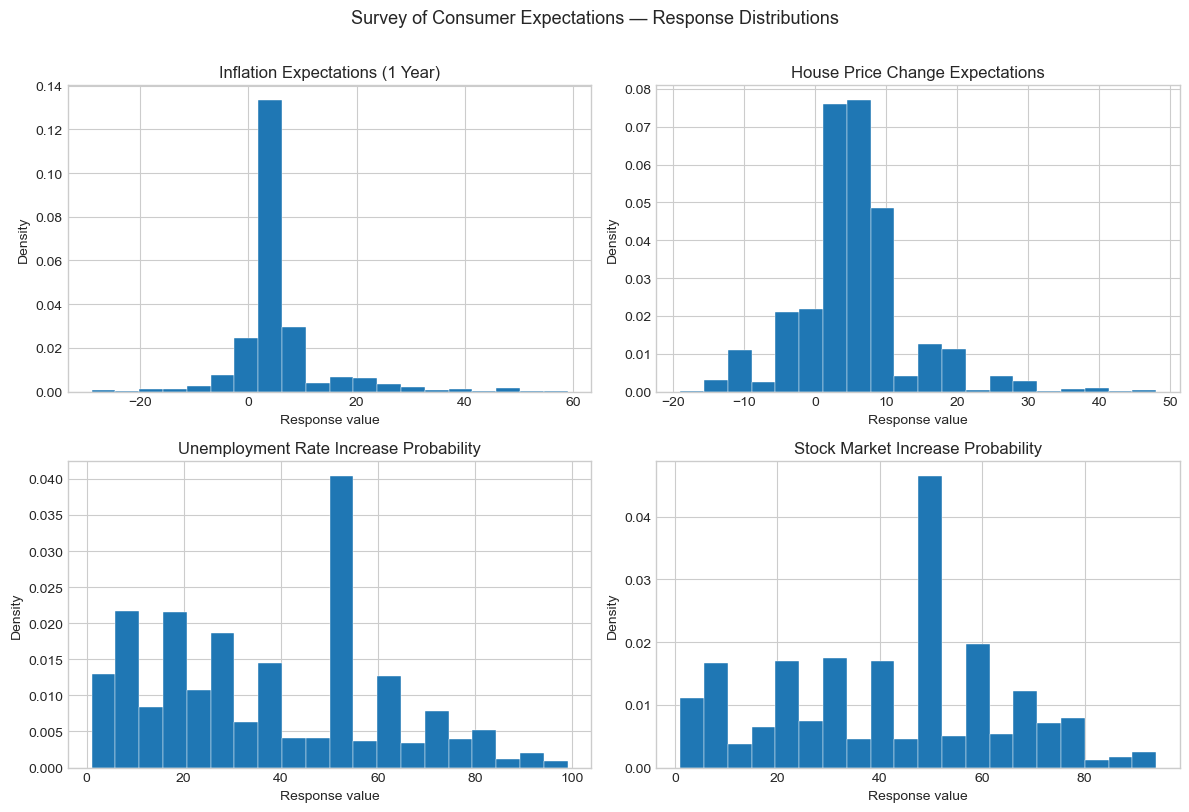

In [18]:
# Step 1 - Histograms of the key expectation variables to visualize their distributions after cleaning
# Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loop through the variables and create histograms
for ax, (col, title) in zip(axes.flat, exp_plot_vars):
    ax.hist(sce_data[col].dropna(), bins=20, edgecolor='white', linewidth=0.3, density=True)
    ax.set_title(title)
    ax.set_xlabel('Response value')
    ax.set_ylabel('Density')

# Overall title and show the plot
fig.suptitle('Survey of Consumer Expectations — Response Distributions', fontsize=13, y=1.01)
_ = plt.tight_layout()

All four distributions show strong bunching at round numbers - respondents tend to report values in multiples of 5 or 10, which is a well-known feature of survey data. Expected inflation is right-skewed with a sharp peak near zero, reflecting that most respondents expect low but positive inflation. Expected house price change is similarly concentrated around small positive values. The probability variables (prob_unrate_up and prob_stocks_up) show pronounced spikes at 50, suggesting many respondents express maximal uncertainty by reporting exactly 50%. Note that these histograms are presented after trimming outliers P1 and P99. The distributions still show signs of some strong outliers, mainly in the first two subplots. 

### 3.2 - Time Series of Key Expectations Variables

In [19]:
# Step 2 - Time series plots of the key expectation variables (monthly averages) to visualize trends and cycles
# Compute monthly means for the expectation variables using the month-end date key (date_me) to group by month
monthly_means = (
    sce_data
    .groupby(pd.Grouper(key='date', freq='ME'))[COLS_EXPECTATIONS]
    .mean()
)

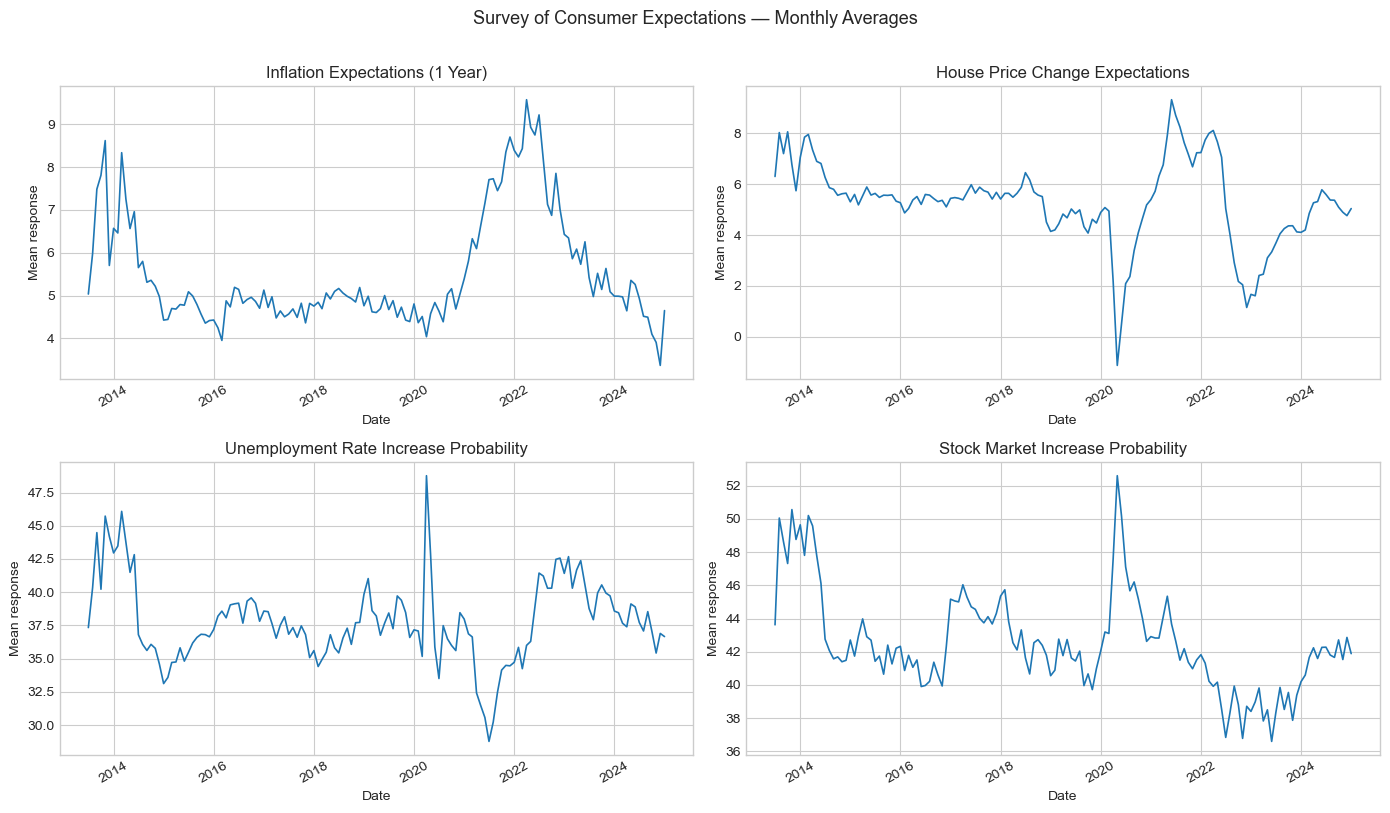

In [20]:
# Create a 2x2 grid of subplots for the expectation variables
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Loop through the variables and create time series plots (Variables and titles defined in the previous step as plot_vars)
for ax, (col, title) in zip(axes.flat, exp_plot_vars):
    ax.plot(monthly_means.index, monthly_means[col], linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Mean response')
    ax.tick_params(axis='x', rotation=30)

# Overall title and show the plot
fig.suptitle('Survey of Consumer Expectations — Monthly Averages', fontsize=13, y=1.01)
_ = plt.tight_layout()

Inflation expectations were elevated in 2013–2014, declined to a stable low around 4–5% through 2015–2019, then surged sharply from 2021 peaking above 9% in 2022 during the post-COVID inflation episode before declining again. House price expectations collapsed in early 2020 (COVID shock) but recovered rapidly. Unemployment pessimism spiked briefly in March–April 2020 before reverting. Stock market optimism has remained persistently below 50% throughout the sample, suggesting consumers are generally pessimistic about equity market gains.

### 3.3 - Time Series of Fraction of Optimists

In [21]:
# Step 3 - Plot the share of optimists over time (monthly averages) to visualize trends and cycles in optimism
# Compute monthly means of the optimism indicators (performed on sce as macro/finance in sce_data is not needed here - computational efficiency)
optimism_means = (
    sce
    .groupby(pd.Grouper(key='date', freq='ME'))[OPTIMISM_COLS]
    .mean()
)

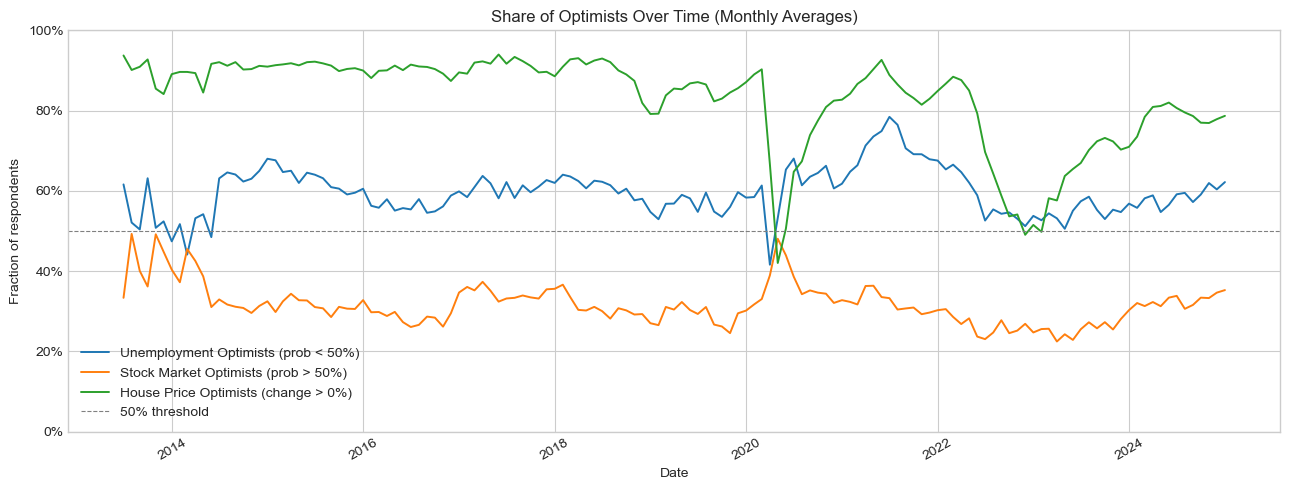

In [22]:
# Initialize the plot
fig, ax = plt.subplots(figsize=(13, 5))

# Plot each optimism indicator over time
for col, title in opt_plot_vars:
    ax.plot(optimism_means.index, optimism_means[col], linewidth=1.4, label=title)

# Format y-axis as percentages, set limits, add a horizontal line at 50%, and finalize the plot
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50% threshold')
ax.set_xlabel('Date')
ax.set_ylabel('Fraction of respondents')
ax.set_title('Share of Optimists Over Time (Monthly Averages)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

_ = plt.tight_layout()

House price optimists consistently make up the large majority of respondents (~85–90% in normal times), reflecting a deeply held belief that house prices tend to rise. Stock market optimists are consistently the minority (~30–35%), suggesting persistent pessimism about equities among households. The COVID shock in early 2020 is visible as a sharp drop in House price and Unemployment optimists, and a spike in Stock market optimists, followed by a rapid recovery. House price optimists also dropped significantly around 2023.

## Part 4 - Exploratory Data Analysis (Macro/Finance)

The macro/finance variables from Part 2 are visualised over the SCE sample period in both levels and changes. Pairwise correlations between the macro/finance variables and the four expectations targets are computed to guide feature selection in Parts 5 and 6.

In [23]:
# Plot prep: create lists of (column, title) pairs for plotting
# Macro vars as levels (original values)
macro_vars = [
    ('cpi', 'Consumer Price Index (CPI)'),
    ('house_price_idx', 'House Price Index'),
    ('federal_funds', 'Federal Funds Rate (%)'),
    ('unemployment', 'Unemployment Rate (%)'),
    ('real_gdp', 'Real GDP (Billions of Chained 2012 Dollars)'),
    ('usd_index', 'US Dollar Index'),
    ('mortgage_30y', '30-Year Fixed Mortgage Rate (%)'),
    ('sp500', 'S&P 500 Index Level'),
    ('wti_crude_oil', 'WTI Crude Oil Price (USD)'),
    ('10y_yield', '10-Year Treasury Yield (%)'),
    ('vix', 'VIX Volatility Index'),
]

# Macro vars as changes (12-month changes for all, plus 1-month changes for non-quarterly series)
macro_vars_changes = [
    ('cpi_chg12m',             'CPI Inflation YoY (%)'),
    ('cpi_chg1m',              'CPI Inflation MoM (%)'),
    ('federal_funds_chg12m',   'Fed Funds Rate 12m Change (pp)'),
    ('federal_funds_chg1m',    'Fed Funds Rate 1m Change (pp)'),
    ('unemployment_chg12m',    'Unemployment Rate 12m Change (pp)'),
    ('unemployment_chg1m',     'Unemployment Rate 1m Change (pp)'),
    ('mortgage_30y_chg12m',    '30Y Mortgage Rate 12m Change (pp)'),
    ('mortgage_30y_chg1m',     '30Y Mortgage Rate 1m Change (pp)'),
    ('usd_index_chg12m',       'USD Index 12m Change (%)'),
    ('usd_index_chg1m',        'USD Index 1m Change (%)'),
    ('house_price_idx_chg12m', 'House Price Index 12m Change (%)'),
    ('real_gdp_chg12m',        'Real GDP 12m Change (%)'),
    ('sp500_chg',              'S&P 500 Monthly Return (%)'),
    ('sp500_chg12m',          'S&P 500 12m Return (%)'),
    ('wti_crude_oil_chg12m',  'WTI Crude Oil 12m Return (%)'),
    ('10y_yield_chg12m',   '10-Year Treasury Yield 12m Change (pp)'),
    ('10y_yield_chg1m',    '10-Year Treasury Yield 1m Change (pp)')
]

### 4.1 - Time-Series of Macro/Finance Variables in Levels

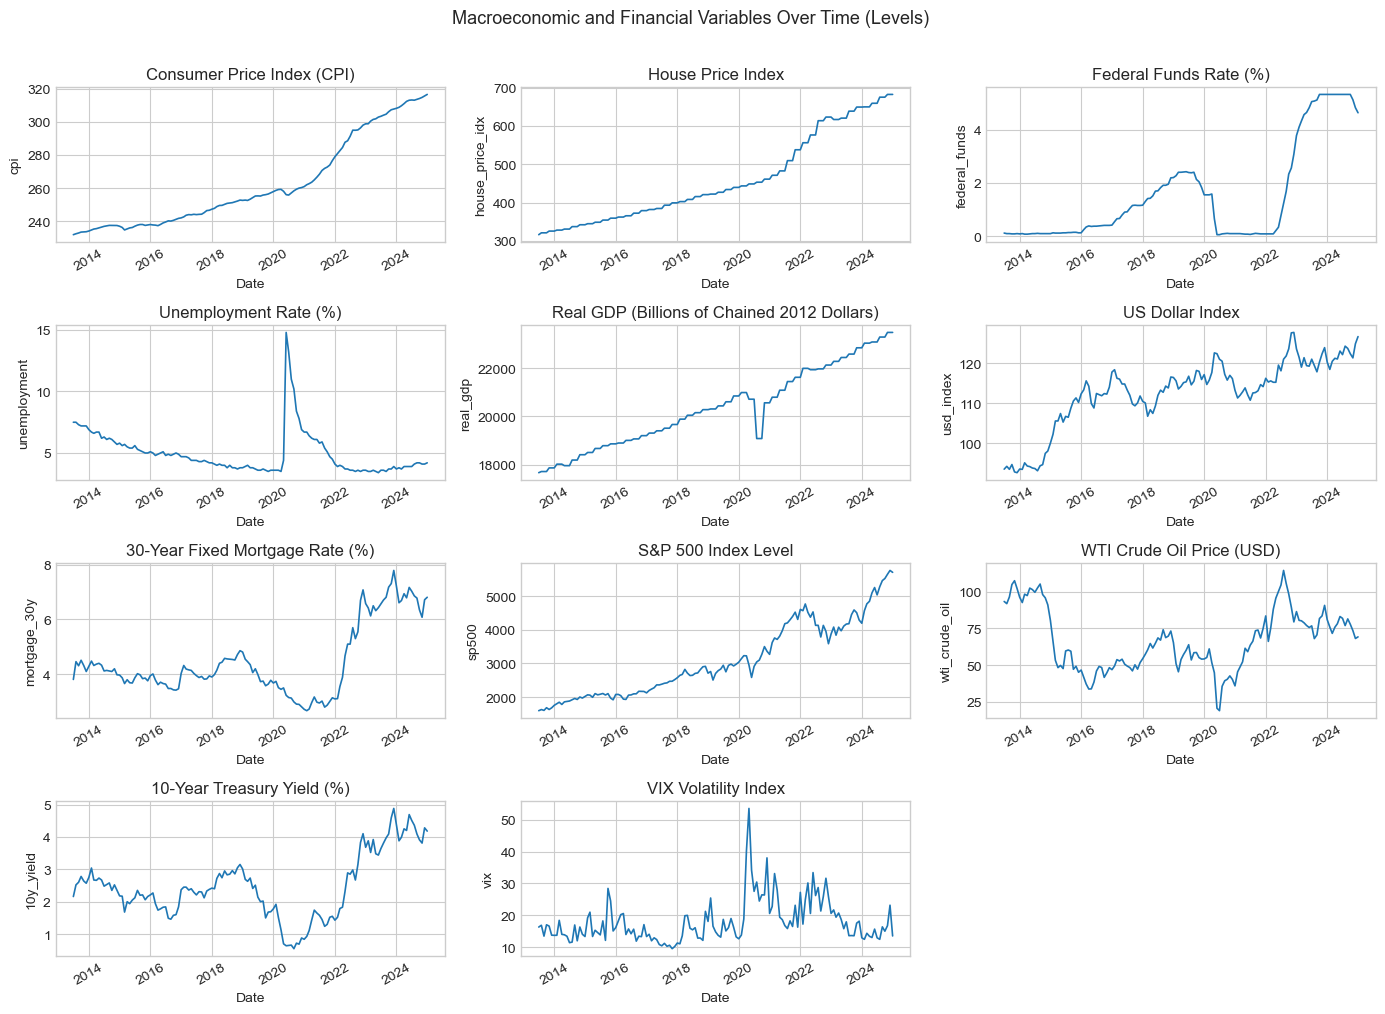

In [24]:
# Step 1 - Plot macro/finance variables in levels over time
# Initialize a 4x3 grid of subplots for the macro/finance variables
fig, axes = plt.subplots(4, 3, figsize=(14, 10))

# Loop through the macro and finance variables and plot each one in a separate subplot
for ax, (col, title) in zip(axes.flat, macro_vars):
    ax.plot(macro_all.index, macro_all[col], linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=30)

# Final adjustments and show the plot
axes.flat[-1].set_visible(False)  # Hide the last empty subplot
fig.suptitle('Macroeconomic and Financial Variables Over Time (Levels)', fontsize=13, y=1.01)
_ = plt.tight_layout()

The levels plots reveal several key macroeconomic trends over the sample period. CPI and house prices grew steadily throughout, with house prices accelerating sharply post-2020. The Federal Funds Rate and mortgage rate dropped to near zero during COVID and rose sharply in 2022–2023 as the Fed tightened monetary policy. Unemployment spiked dramatically in early 2020 before recovering rapidly. The S&P 500 trended upward throughout with a sharp correction in early 2020. WTI crude oil was volatile, collapsing in 2020 before recovering. VIX spiked sharply in early 2020, reflecting peak market uncertainty during the pandemic.

### 4.2 - Time-Series of Macro/Finance Variables in Changes

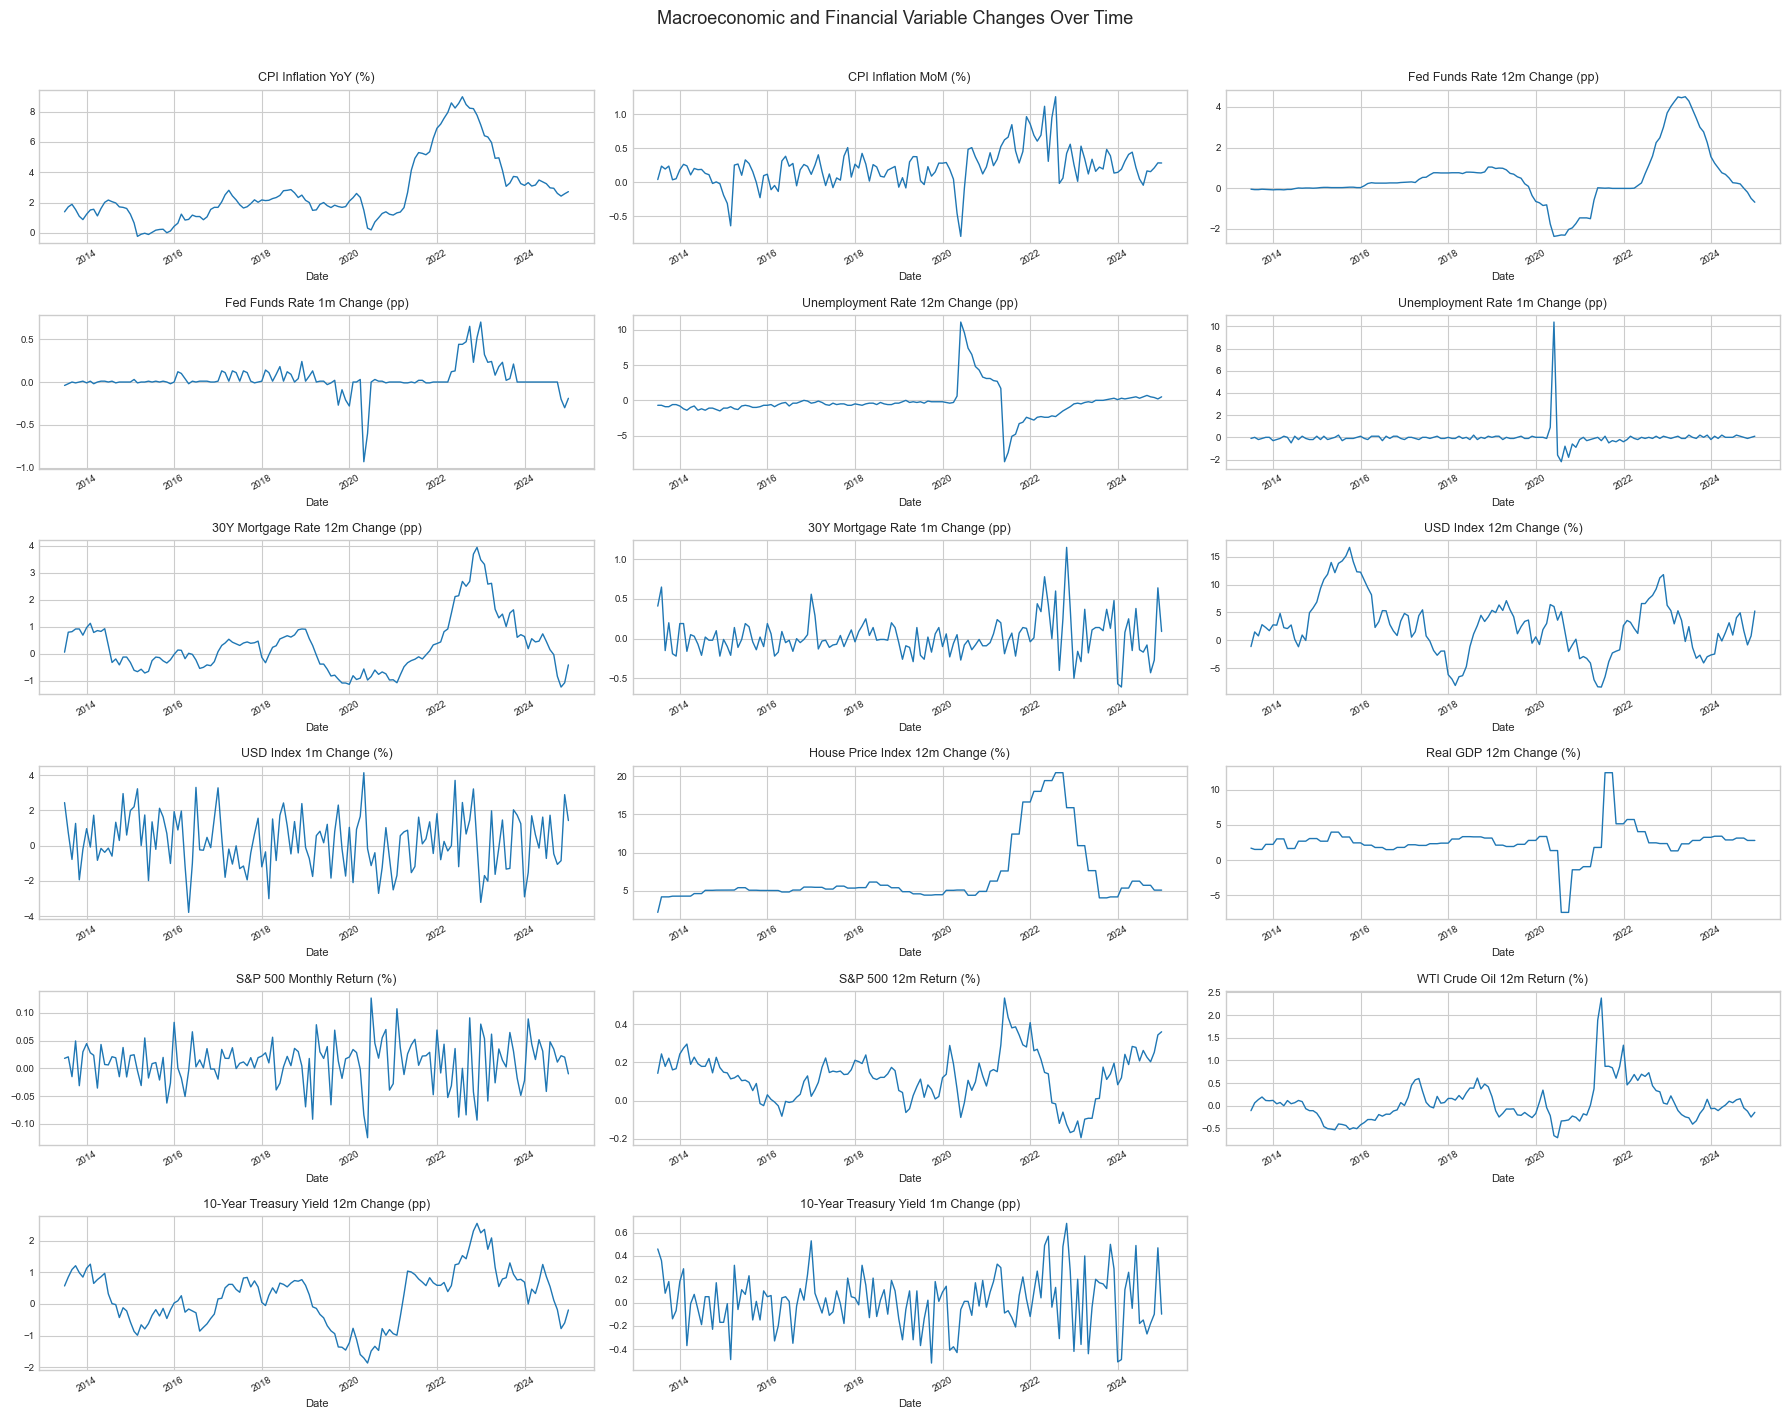

In [25]:
# Step 2 - Plot macro/finance variables in relative/absolute changes over time
# Initialize a 6x3 grid of subplots for the macro/finance variables in changes
fig, axes = plt.subplots(6, 3, figsize=(18, 14))

# Loop through the macro and finance variables in changes and plot each one in a separate subplot
for ax, (col, title) in zip(axes.flat, macro_vars_changes):
    ax.plot(macro_all.index, macro_all[col], linewidth=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Date', fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

# Final adjustments and show the plot
fig.suptitle('Macroeconomic and Financial Variable Changes Over Time', fontsize=13, y=1.01)
axes.flat[-1].set_visible(False)  # Hide the last empty subplot
_ = plt.tight_layout()

The changes plots highlight episodes of macroeconomic stress more clearly than the levels. CPI inflation surged in 2021–2022 to multi-decade highs before declining. The Federal Funds Rate saw its largest 12-month increase in decades during 2022–2023. Unemployment changes were dominated by the COVID shock. S&P 500 and WTI returns show high volatility throughout, with large negative values in early 2020. The 10-year yield changes mirror the Federal Funds Rate, rising sharply in 2022.

### 4.3 - Macro/Finance Variables Correlation with Key Expectations Variables

Note: This step is performed using HTML-tables to display them side-by-side with all four sorted by correlation strength. With regular dataframes, there would have been a trade-off between plotting them one over the other sorted correctly, or side-by-side only sorted for the first variable. 

In [26]:
# Step 3 - Correlation between macro/finance variables and expectations variables
# Build all four styled tables as HTML strings
html_tables = []
for target in COLS_EXPECTATIONS:
    corr = (
        sce_data[MACRO_COLS]
        .corrwith(sce_data[target])
        .rename('correlation')
        .to_frame()
        .assign(abs_corr=lambda df: df['correlation'].abs())
        .sort_values('abs_corr', ascending=False)
        .drop(columns='abs_corr')
    )
    styled = (corr.style
                  .background_gradient(cmap='RdBu', vmin=-0.15, vmax=0.15)
                  .format("{:.2f}")
                  .set_caption(f"Correlations with {target}"))
    html_tables.append(styled.to_html())

# Wrap in a flex row and display once
display(HTML(
    '<div style="display:flex; gap:20px; align-items:flex-start;">'
    + ''.join(f'<div>{t}</div>' for t in html_tables)
    + '</div>'
))

,correlation
house_price_idx_chg12m,0.13
cpi_chg12m,0.12
wti_crude_oil_chg12m,0.09
cpi_chg1m,0.09
wti_crude_oil,0.08
10y_yield_chg12m,0.08
mortgage_30y_chg12m,0.07
sp500,0.06
unemployment_chg12m,-0.06
house_price_idx,0.05


Overall correlations between macro/finance variables and expectations are modest, with no variable exceeding 0.13 in absolute value. This suggests that macro variables alone have limited predictive power for individual-level expectations, which is consistent with the literature on heterogeneous beliefs. The strongest predictors of inflation expectations are house price momentum (house_price_idx_chg12m) and CPI changes, which is intuitive. For house price expectations, S&P 500 12-month returns and WTI crude oil returns are most correlated, suggesting that financial market sentiment spills over into housing expectations. Unemployment and stock market expectations show weaker macro correlations overall. VIX shows modest negative correlations with house_price_chg and prob_stocks_up, consistent with the view that higher uncertainty suppresses optimism about asset prices. Note that correaltions are computed on the full data set - not split in train and test.

## Part 5 - Predicting Contiuous Expectation Variables

This section fits regression models to predict the four continuous expectations variables. We follow a two-step approach: first using only macro/finance variables as features, then augmenting with individual-level SCE variables. For each model we use 5-fold cross-validation to select hyperparameters where applicable, plot validation curves, and evaluate performance on the 2024 test set using RMSE and R².

For the macro/finance features, we include some levels, some 12-month changes and 1-month change for one variable. Levels capture the current macroeconomic environment (e.g. a high federal funds rate signals tight monetary policy), while changes capture recent momentum and surprises. From the 12-month change variables we select the house price index, cpi, wti crude oil, sp500 and unemployment. In 1-month changes we include cpi, and in levels unemployment, federal funds, mortgage 30y, 10y yield and vix. All of these have relatively strong correlation with the targets, compared to the rest of the data set. 

For the individual-level SCE features, we select variables based on the correlation analysis below. Income rank, education, and numerical literacy show the strongest correlations with the target variables and are therefore included. female, black and working (indicators) are also included as they show consistent correlations across multiple targets. Multicollinearity between the literacy variables is highly likely, but we still want to include a few of them: we pick q2, q3, and q6, as they display consistently high correlation with the targets. The multicollinearity will be handled for all models except OLS through regularization. educ is included as a categorical variable and one-hot encoded.

Model descriptions:

We fit five models for each target variable and feature set:

- **OLS**: No Hyperparameters. Requires feature scaling (StandardScaler applied). Serves as the baseline.
- **Ridge**: L2 regularization with penalty strength α. Requires feature scaling. α selected via 5-fold Cross Validation.
- **Lasso**: L1 regularization with penalty strength α. Requires feature scaling. α selected via 5-fold Cross Validation. Can shrink coefficients to exactly zero, effectively performing feature selection.
- **ElasticNet**: Combines L1 and L2 regularization. Requires feature scaling. Both α and l1_ratio selected via 5-fold Cross Validation. 
- **DecisionTree**: No feature scaling needed. max_depth selected via 5-fold Cross Validation. Captures non-linear relationships. 

### 5.0 - Setup

In [27]:
# For choice of SCE predictors - correlation with targets 

# Build all four styled tables as HTML strings
html_tables = []
for target in COLS_EXPECTATIONS:
    corr = (
        sce_data[COLS_FIRST_WAVE + COLS_INDIVIDUAL]
        .corrwith(sce_data[target])
        .rename('correlation')
        .to_frame()
        .assign(abs_corr=lambda df: df['correlation'].abs())
        .sort_values('abs_corr', ascending=False)
        .drop(columns='abs_corr')
    )
    styled = (corr.style
                  .background_gradient(cmap='RdBu', vmin=-0.15, vmax=0.15)
                  .format("{:.2f}")
                  .set_caption(f"Correlations with {target}"))
    html_tables.append(styled.to_html())

# Wrap in a flex row and display once
display(HTML(
    '<div style="display:flex; gap:20px; align-items:flex-start;">'
    + ''.join(f'<div>{t}</div>' for t in html_tables)
    + '</div>'
))

,correlation
hh_inc_bin_rank,-0.17
educ,-0.16
num_lit_q2_correct,-0.16
num_lit_q6_correct,-0.14
num_lit_q3_correct,-0.13
female,0.13
black,0.12
num_lit_q5_correct,-0.10
owner,-0.07
couple,-0.06


In [28]:
# Feature sets for Part 5 - Chosen based on Correlation analysis and theoretical considerations.
NUM_MACRO = [
    "house_price_idx_chg12m", "cpi_chg12m", "cpi_chg1m",
    "wti_crude_oil_chg12m", "sp500_chg12m",
    "unemployment_chg12m", "unemployment",
    "federal_funds", "mortgage_30y", "10y_yield",
    "vix",
]
# SCE variables that don't need encoding.
NUM_SCE = ["num_lit_q2_correct", "num_lit_q3_correct", 'num_lit_q6_correct', "female", "black",
           "hh_inc_bin_rank", "working"]
# SCE Variable that does need encoding (education levels are categorical and not ordinal, so we will one-hot encode them)
ENCODE_SCE = ["educ"]

# Combine feature sets into a dictionary for easy access in modeling and plotting
FEATURE_SETS = {
    "Macro only":  (NUM_MACRO,            []),
    "Macro + SCE": (NUM_MACRO + NUM_SCE,  ENCODE_SCE),
}

# Use existing COLS_EXPECTATIONS - Rename for clarity that these are the target variables for modeling
TARGETS = COLS_EXPECTATIONS

# Link target variable names to more descriptive labels for plotting and interpretation
TARGET_LABELS = {
    "infl_1y":            "Inflation Expectation (1y, %)",
    "house_price_change": "Expected House Price Change (%)",
    "prob_unrate_up":     "P(Unemployment Up, next 12m, %)",
    "prob_stocks_up":     "P(Stocks Up, next 12m, %)",
}

In [29]:
# Model configuration: estimator, param_grid, scaling, plotting preferences - Allows for easy iteration over different models and consistent plotting
MODELS = {
    # OLS - No hyperparameters, feature scaling applied, linear x-axis for plotting
    "OLS": {
        "estimator": LinearRegression(),
        "param_grid": None,
        "scale": True,
        "param_name": None,
        "log_x": False,
    },
    # Ridge - Hyperparameter alpha, logarithmic grid, feature scaling applied, log x-axis for plotting to capture wide range of alpha values
    "Ridge": {
        "estimator": Ridge(),
        "param_grid": {"estimator__alpha": np.logspace(-2, 6, 20)},
        "scale": True,
        "param_name": "estimator__alpha",
        "log_x": True,
    },
    # Lasso - Hyperparameter alpha, logarithmic grid, feature scaling applied, log x-axis for plotting
    "Lasso": {
        "estimator": Lasso(random_state=0, max_iter=5000),
        "param_grid": {"estimator__alpha": np.logspace(-4, 6, 20)},
        "scale": True,
        "param_name": "estimator__alpha",
        "log_x": True,
    },
    # ElasticNet - Hyperparameters alpha and l1_ratio, logarithmic grid for alpha, feature scaling applied, log x-axis for plotting
    "ElasticNet": {
        "estimator": ElasticNet(random_state=0, max_iter=5000),
        "param_grid": {
            "estimator__alpha": np.logspace(-4, 6, 20),
            "estimator__l1_ratio": [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0],
        },
        "scale": True,
        "param_name": "estimator__alpha",  # x-axis for validation curve
        "log_x": True,
    },
    # Decision Tree Regressor - Hyperparameter max_depth, linear grid, no feature scaling needed, linear x-axis for plotting
    "Tree": {
        "estimator": DecisionTreeRegressor(random_state=0),
        "param_grid": {"estimator__max_depth": [1, 2, 3, 4, 5, 7, 10, 15, None]},
        "scale": False,
        "param_name": "estimator__max_depth",
        "log_x": False,
    },
}

# Define colors for each model for consistent plotting
COLORS = {
    "OLS":        "tab:purple",
    "Ridge":      "darkorange",
    "Lasso":      "tab:green",
    "ElasticNet": "tab:blue",
    "Tree":       "saddlebrown",
}

In [30]:
# Train/Test Split (2024)
train = sce_data[sce_data["date"].dt.year < 2024].reset_index(drop=True)
test  = sce_data[sce_data["date"].dt.year == 2024].reset_index(drop=True)

In [31]:
# Reusable function to create a ColumnTransformer for preprocessing based on the specified numeric and categorical columns, with optional scaling for numeric features
def make_preprocessor(num_cols, cat_cols, scale=True):
    """
    Create a ColumnTransformer for preprocessing numeric and categorical features.

    Parameters
    ----------
    num_cols : list[str]
        Names of numeric feature columns. StandardScaler is applied if scale=True,
        otherwise passed through unchanged.
    cat_cols : list[str]
        Names of categorical feature columns. OneHotEncoder with drop="first" is applied.
    scale : bool, optional
        Whether to standardize numeric features. Default is True.

    Returns
    -------
    ColumnTransformer
        Configured transformer ready to be embedded in a Pipeline.
    """
    # Initialize an empty list to hold the transformers for numeric and categorical features
    transformers = []

    # Add numeric transformer if there are numeric columns specified
    if num_cols:
        transformers.append(("num", StandardScaler() if scale else "passthrough", num_cols))

    # Add categorical transformer if there are categorical columns specified
    if cat_cols:
        transformers.append((
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            cat_cols
        ))

    # Create and return the ColumnTransformer with the specified transformers
    return ColumnTransformer(transformers)

In [32]:
# Reusable model to fit regressions with optional hyperparameter tuning using GridSearchCV, returning the fitted pipeline and CV results if applicable
def fit_model(X, y, model_cfg, num_cols, cat_cols, cv_folds=5, PART_6=False):
    """
    Fit a model pipeline with optional hyperparameter tuning via GridSearchCV.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    y : array-like
        Target vector.
    model_cfg : dict
        Model configuration with keys "estimator", "scale", "param_grid", and "param_name".
    num_cols : list[str]
        Numeric feature column names passed to the preprocessor.
    cat_cols : list[str]
        Categorical feature column names passed to the preprocessor.
    cv_folds : int, optional
        Number of cross-validation folds. Default is 5.
    PART_6 : bool, optional
        If True, uses ROC-AUC scoring instead of MSE. Default is False.

    Returns
    -------
    dict
        Keys: "pipeline" (fitted estimator), "has_cv" (bool), and optionally
        "best_params", "best_score", and "cv_results" when GridSearchCV is used.
    """
    # Create a preprocessing pipeline based on the specified numeric and categorical columns, with optional scaling for numeric features
    pre = make_preprocessor(num_cols, cat_cols, scale=model_cfg["scale"])
    pipe = Pipeline([
        ("preprocessor", pre),
        ("estimator", clone(model_cfg["estimator"])),
    ])
    
    # If no hyperparameter tuning is specified, fit the pipeline directly and return the fitted model
    if model_cfg["param_grid"] is None:
        pipe.fit(X, y)
        return {
            "pipeline": pipe,
            "has_cv": False,
        }
    
    # For Part 6, where targets are binary, we switch to ROC-AUC as the scoring metric to evaluate classification performance instead of regression performance.
    scoring = "neg_mean_squared_error" if not PART_6 else "roc_auc"

    # Set up GridSearchCV with the specified pipeline, hyperparameter grid, cross-validation folds, and scoring metric. Fit it to the data to find the best hyperparameters.
    gs = GridSearchCV(
        pipe,
        model_cfg["param_grid"],
        cv=cv_folds,
        scoring=scoring,
        n_jobs=-1,
        refit=True,
    )
    gs.fit(X, y)

    # Return the best estimator along with CV results and best hyperparameters if applicable - negate MSE to make it positive
    return {
        "pipeline": gs.best_estimator_,
        "has_cv": True,
        "best_params": gs.best_params_,
        "best_score": -gs.best_score_ if not PART_6 else gs.best_score_,
        "cv_results": gs.cv_results_,
    }

In [33]:
# Reusable function to extract validation curve data for plotting.
def collect_validation_curve_data(model_name, model_cfg, model_res, PART_6=False):
    """
    Extract validation curve data for a single model, ready for plotting.

    Parameters
    ----------
    model_name : str
        Name of the model (used to detect ElasticNet special-casing).
    model_cfg : dict
        Model configuration dict containing "param_name" and "log_x" keys.
    model_res : dict
        Result dict returned by fit_model, containing "cv_results" and "best_params".
    PART_6 : bool, optional
        If True, scores are ROC-AUC (higher is better); otherwise MSE (lower is better).
        Default is False.

    Returns
    -------
    tuple or None
        (x_vals, y_vals, best_x, best_y, param_label) arrays and the stripped
        parameter label, or None if the model has no CV or no param_name.
    """
    # Check if the model has CV results and a parameter name for plotting; if not, return None to indicate no validation curve data
    if not model_res.get("has_cv", False):
        return None
    
    param_name = model_cfg["param_name"]
    if param_name is None:
        return None

    # Extract the CV results and prepare data for plotting the validation curve
    cv_res = model_res["cv_results"]

    # Extract the parameter column, e.g. "param_estimator__alpha"
    param_vals = np.array(cv_res[f"param_{param_name}"].data, dtype=float)

    # Extract the mean test scores and negate if using MSE (so that higher is better for plotting) ROC-AUC stays positive
    if not PART_6:
        scores = -cv_res["mean_test_score"]          
    else:
        scores = cv_res["mean_test_score"]        

    # If the model is ElasticNet, we need to filter the results to only include the best l1_ratio for plotting the alpha curve
    if model_name == 'ElasticNet' and not PART_6:
        # Find the best l1_ratio and filter to only show MSE for that l1_ratio
        best_l1 = model_res['best_params'].get('estimator__l1_ratio', None)
        if best_l1 is not None:
            l1_vals = np.array(cv_res["param_estimator__l1_ratio"].data)
            mask = np.isclose(l1_vals.astype(float), best_l1)
            param_vals = param_vals[mask]
            scores = scores[mask]

    # Store the x and y values for plotting
    x = param_vals
    y = scores

    # Identify the best point on the curve (lowest MSE or highest accuracy) for highlighting in the plot
    best_idx = np.argmin(y) if not PART_6 else np.argmax(y)
    best_x = x[best_idx]
    best_y = y[best_idx]

    # For the axis label, strip the "estimator__" prefix
    param_label = param_name.split("estimator__", 1)[-1]
    return x, y, best_x, best_y, param_label

In [34]:
# Reusable function to format the best_params dictionary from GridSearchCV into a clean string for display in plots and tables
def format_params(params):
    """
    Convert a GridSearchCV best_params dict into a short, readable string.

    Parameters
    ----------
    params : dict or None
        Mapping of full parameter names (e.g. "estimator__alpha") to their
        best values. If None, an empty string is returned.

    Returns
    -------
    str
        Comma-separated "key=value" pairs with the "estimator__" prefix stripped
        and float values formatted to 4 significant digits.
    """
    # If params is None, return an empty string to indicate no parameters to display
    if params is None:
        return ""
    # Iterate through the parameters, extract the relevant part of the parameter name, and format the value for display
    parts = []
    for k, v in params.items():
        # Only keep the part after 'estimator__'
        short_k = k.split("estimator__", 1)[-1]
        # Format float values with 4 significant digits for cleaner display; otherwise, just show the value
        if isinstance(v, (float, np.floating)):
            parts.append(f"{short_k}={float(v):.4g}")
        else:
            parts.append(f"{short_k}={v}")
    
    # Join all parameter parts into a single string separated by commas for display
    return ", ".join(parts)

In [35]:
# Reusable function to run the entire modeling and validation curve process for a given target variable and feature set
def run_cv_for_target(train, target, num_cols, cat_cols, feature_set_name, PART_6=False):
    """
    Fit all models for a target variable, print CV summaries, and plot validation curves.

    Parameters
    ----------
    train : pd.DataFrame
        Training DataFrame containing features and the target column.
    target : str
        Name of the target column to model.
    num_cols : list[str]
        Numeric feature column names.
    cat_cols : list[str]
        Categorical feature column names.
    feature_set_name : str
        Label for the feature set used in printed output and plot titles.
    PART_6 : bool, optional
        If True, uses classification models and ROC-AUC scoring. Default is False.

    Returns
    -------
    dict
        Mapping model_name -> result dict as returned by fit_model.
    """
    # Prepare the feature matrix X and target vector y from the training data based on the specified numeric and categorical columns and the target variable
    X = train[num_cols + cat_cols]
    y = train[target]
    # Print the target variable and feature set being used for this run, and initialize a dictionary to store results for each model
    print(f"\n── {target} ({feature_set_name}) ──")
    results = {}

    # Fit all models and print nicely formatted summary
    for model_name, cfg in MODELS.items():
        # Fit the model using the fit_model function, which handles preprocessing, model fitting, and hyperparameter tuning if applicable
        res = fit_model(X, y, cfg, num_cols, cat_cols, cv_folds=5, PART_6=PART_6)
        # Store the results for this model in the results dictionary for later use in plotting validation curves
        results[model_name] = res
        # Print the results for this model, including the best hyperparameters and CV score if applicable; if no CV was performed, indicate that in the output
        if res.get("has_cv", False):
            best_mse = res["best_score"]
            best_params = res["best_params"]
            params_str = format_params(best_params)
            metric_name = "CV MSE" if not PART_6 else "CV ROC-AUC"
            print(f"  {model_name:11s} {params_str:35s}  {metric_name}={best_mse:.4f}")
        else:
            print(f"  {model_name:11s} (no hyperparameter tuning)")

    # 2×2 grid when part 5, 1x3 for part 6 and specify models
    if not PART_6:
        curve_models = ["Ridge", "Lasso", "ElasticNet", "Tree"]
        fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    else:
        curve_models = ['LogisticRegression', 'RandomForest', 'HistGradientBoosting']
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes = axes.flatten()

    # Loop through models, collect validation curve data, and plot it.
    for ax, mname in zip(axes, curve_models):
        cfg = MODELS[mname]
        res = results[mname]
        curve_data = collect_validation_curve_data(mname, cfg, res, PART_6=PART_6)
        # If there is no CV data for this model (e.g. OLS), skip the plot and indicate that in the title
        if curve_data is None:
            ax.set_title(mname + " (no CV)")
            ax.axis("off")
            continue
        # Unpack the curve data for plotting
        x, y, best_x, best_y, param_label = curve_data

        # Select which axis scale to use based on the model configuration
        if cfg.get("log_x", False):
            ax.semilogx(x, y, marker="o", markersize=3)
        else:
            ax.plot(x, y, marker="o", markersize=3)

        # Highlight the best point on the curve and annotate it with the best hyperparameter value and corresponding CV score for easy interpretation
        ax.axvline(best_x, color="red", ls="--", lw=1)
        ax.set(
            xlabel=param_label,
            ylabel="CV MSE" if not PART_6 else "CV ROC-AUC",
            title=mname,
        )
        ax.text(
            0.05, 0.95,
            f"Best {param_label}={best_x:.3g}\n{metric_name}={best_y:.3f}" if not PART_6 else f"Best {param_label}={best_x:.3g}\n{metric_name}={best_y:.3f}",
            transform=ax.transAxes,
            va="top", ha="left",
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
        )
    # Set the overall title for the figure, adjust layout, and display the plot
    fig.suptitle(
        f"Validation curves — {TARGET_LABELS.get(target, target)} ({feature_set_name})",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

    # Stores the results for all models for this target and feature set in a dictionary for later analysis or plotting
    return results

In [36]:
# Monthly aggregation helper
def monthly_mean(dates, values):
    """
    Aggregate a series of values to a monthly mean indexed by month-start timestamps.

    Parameters
    ----------
    dates : array-like of datetime
        Interview or observation dates corresponding to each value.
    values : array-like
        Numeric values to aggregate.

    Returns
    -------
    pd.Series
        Monthly mean values indexed by month-start timestamps, sorted ascending.
    """
    # Create a DataFrame from the input dates and values, then extract the month (as a period) and convert it to a timestamp representing the start of the month for grouping
    df = pd.DataFrame({"date": dates, "value": values})
    df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

    return df.groupby("month")["value"].mean().sort_index()

In [37]:
# Plot actual vs predicted (monthly)
def plot_predictions(results, train, test, target, num_cols, cat_cols, feature_set_name, split_date="2024-01-01", PART_6=False):
    """
    Plot monthly-averaged actual vs. predicted values for all fitted models.

    Parameters
    ----------
    results : dict
        Mapping model_name -> {"pipeline": fitted_pipeline, ...}.
    train : pd.DataFrame
        Training DataFrame containing features and the target column.
    test : pd.DataFrame
        Test DataFrame containing features and the target column.
    target : str
        Name of the target column to plot.
    num_cols : list[str]
        Numeric feature column names.
    cat_cols : list[str]
        Categorical feature column names.
    feature_set_name : str
        Label for the feature set used in the plot title.
    split_date : str, optional
        ISO date string marking the train/test split. Default is "2024-01-01".
    PART_6 : bool, optional
        Flag indicating whether to display the plot for PART_6. Default is False.

    Returns
    -------
    None
        Displays a matplotlib figure; no value is returned.
    """
    # Combine numeric and categorical columns into a single list of features for prediction
    features = num_cols + cat_cols

    # Predictions - Combine train and test, compute monthly means
    full = pd.concat([train, test]).reset_index(drop=True)
    actual = monthly_mean(full["date"], full[target])

    # Set up the plot
    fig, ax = plt.subplots(figsize=(11, 4.5))

    # Plot the actual monthly mean values of the target variable over time as a black line for reference
    ax.plot(actual.index, actual.values, color="black", lw=1.5, label="Actual")

    # Loop through models, predict values using the fitted pipelines, aggregate to monthly means, and plot them with different colors and dashed lines for distinction
    for model_name, mr in results.items():
        pipe = mr["pipeline"]
        # For classification models, we want to predict probabilities and then take the mean to get the average predicted probability for each month
        if hasattr(pipe, "predict_proba"):
            raw = pipe.predict_proba(full[features])[:, 1]  # probability of class 1
        else:
            raw = pipe.predict(full[features])
        # Aggregate the raw predictions to monthly means using the same monthly_mean function for consistency with the actual values, and plot them on the same axes for comparison
        pred = monthly_mean(full["date"], raw)
        ax.plot(pred.index, pred.values, color=COLORS[model_name],
                ls="--", lw=1, label=model_name)
        
    # Add a vertical line to indicate the train/test split date
    ax.axvline(pd.Timestamp(split_date), color="red", ls=":", lw=1.5,
               label="Train/Test split")
    
    # Set axis labels, title, legend, adjust layout, and display the plot
    ax.set(
        xlabel="Date",
        ylabel=TARGET_LABELS.get(target, target),
        title=f"{TARGET_LABELS.get(target, target)} — {feature_set_name}",
    )
    ax.legend(fontsize=8, ncol=3)

    # Display
    plt.tight_layout()
    plt.show()

In [38]:
# Compute test metrics (RMSE and R²) for all models - Part 6 gets its own classification specific helper.
def test_metrics(results, test, target, num_cols, cat_cols, feature_set_name):
    """
    Compute RMSE and R² on the test sample for each fitted regression model.

    Parameters
    ----------
    results : dict
        Mapping model_name -> {"pipeline": fitted_pipeline, ...}.
    test : pd.DataFrame
        Test DataFrame containing features and the target column.
    target : str
        Name of the target column.
    num_cols : list[str]
        Numeric feature column names.
    cat_cols : list[str]
        Categorical feature column names.
    feature_set_name : str
        Label for the feature set (e.g. "Macro", "Macro + SCE").

    Returns
    -------
    pd.DataFrame
        One row per model with columns feature_set, target, model, RMSE, and R2.
    """
    # Combine numeric and categorical columns into a single list of features for prediction
    features = num_cols + cat_cols

    # Prepare the test feature matrix and target vector for evaluation
    X_te = test[features]
    y_te = test[target].values

    rows = []
    # Loop through each model, predict through pipeline, compute RMSE and R² against true test values
    for model_name, mr in results.items():
        pipe = mr["pipeline"]
        y_pred = pipe.predict(X_te)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        r2   = r2_score(y_te, y_pred)
        # Append the results for this model to the rows list
        rows.append({
            "feature_set": feature_set_name,
            "target": target,
            "model": model_name,
            "RMSE": rmse,
            "R2": r2,
        })

    return pd.DataFrame(rows)

### 5.1 - Macro/Finance-Features Only 

Note: Part 5 only has one scoring metric per model with hyperparameter - its score is reported on training data through CV-overview and on test data in the final table. This holds for Part 5.2 as well.


── infl_1y (Macro only) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=2976                           CV MSE=70.3216
  Lasso       alpha=0.01274                        CV MSE=70.2008
  ElasticNet  alpha=0.01274, l1_ratio=1            CV MSE=70.2008
  Tree        max_depth=2                          CV MSE=70.9571


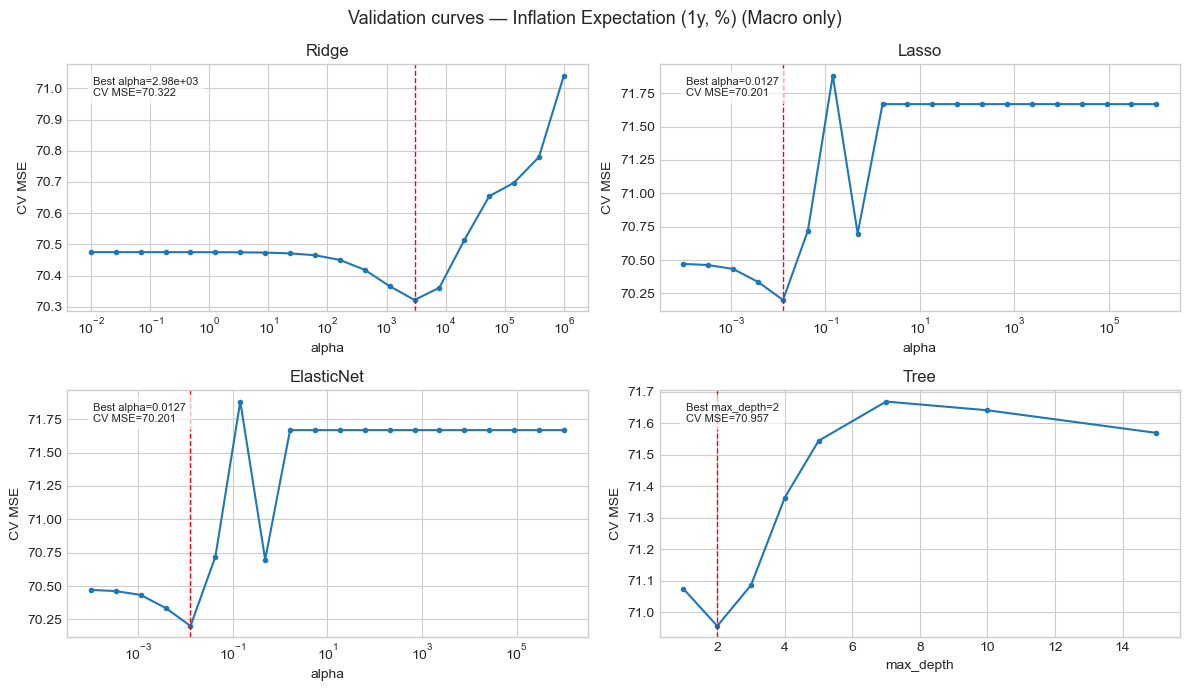

In [39]:
# Initialize result storing structures
all_metrics = []
macro_only_results = {}

# Initialize numerical and categorical feature lists for the "Macro only" feature set
num, cat = FEATURE_SETS["Macro only"]

# Inflation expectation (1 year) target
target = "infl_1y"

# Run CV, store results and compute test metrics for the "Macro only" feature set
res = run_cv_for_target(train, target, num, cat, "Macro only")
macro_only_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro only"))

Ridge selects α ≈ 2 980. The validation curve is relatively flat for small α values, decreases to a clear minimum, and rises sharply for larger values, confirming the search range is appropriate. Lasso needs very little regularization (α ≈ 0.013), indicating that most macro features contribute meaningfully. ElasticNet collapses to the same solution with l1_ratio=1, making it identical to Lasso and confirming the Ridge component adds no value here. The Decision Tree prefers depth 2, with CV MSE rising for deeper trees, suggesting limited predictive structure in the macro features.

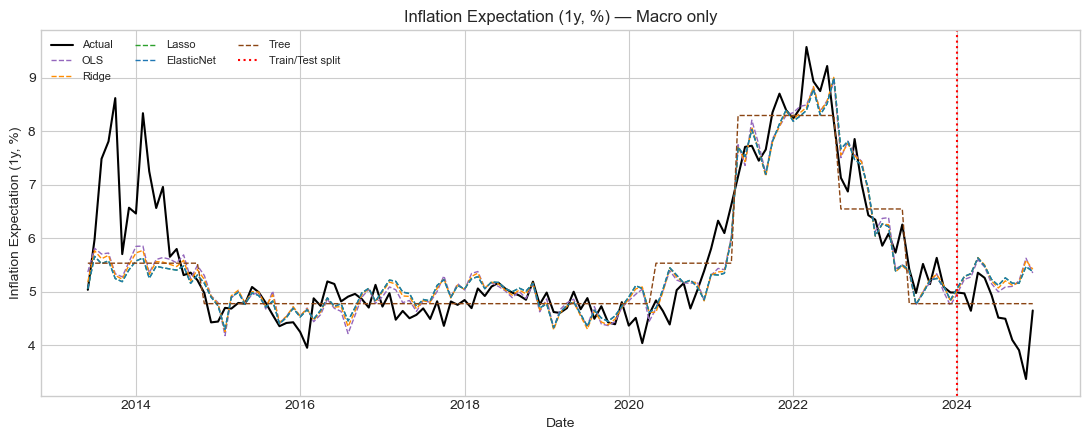

In [40]:
plot_predictions(res, train, test, target, num, cat, "Macro only")

All linear models track the broad inflation trend reasonably well, capturing the 2021–2022 surge and subsequent decline, but miss the sharp spikes in 2013–2014 and fail to capture month-to-month variation. The Decision Tree produces a step-function pattern, predicting a near-constant ~5% from 2015–2020 before stepping up to a higher level around 2021 and returning later, following the Covid spike and return quite closely.


── house_price_change (Macro only) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=2.069e+04                      CV MSE=58.2148
  Lasso       alpha=0.1438                         CV MSE=58.5585
  ElasticNet  alpha=0.1438, l1_ratio=0.01          CV MSE=58.2118
  Tree        max_depth=1                          CV MSE=60.3531


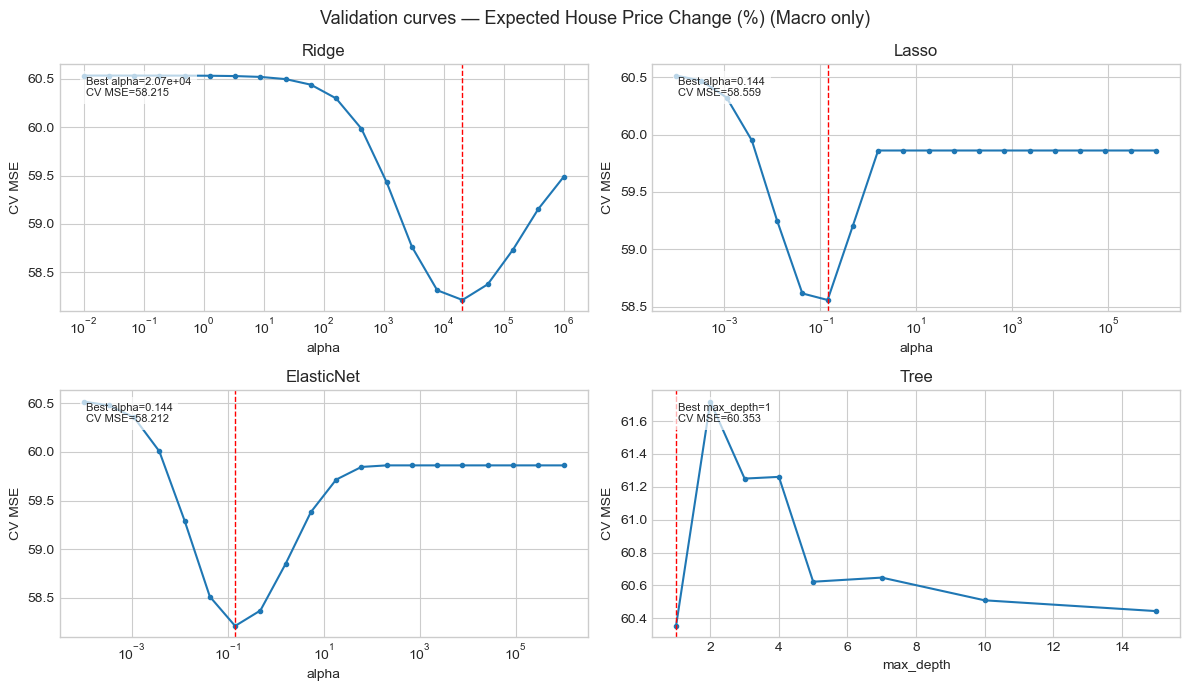

In [41]:
# House price change expectation target
target = "house_price_change"

# Run CV, store results and compute test metrics for the "Macro only" feature set
res = run_cv_for_target(train, target, num, cat, "Macro only")
macro_only_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro only"))

Ridge selects α ≈ 20,700, indicating that heavy regularization is needed and that the macro features have limited signal for this target. The validation curve decreases steadily to a clear minimum before rising again. Lasso selects α ≈ 0.144 with a well-defined minimum. ElasticNet selects the same α with l1_ratio=0.01, effectively behaving as Ridge and achieving a slightly lower CV MSE than Lasso. The Decision Tree prefers depth 1, though its validation curve is non-monotonic for deeper trees, suggesting no stable predictive structure beyond a single split.

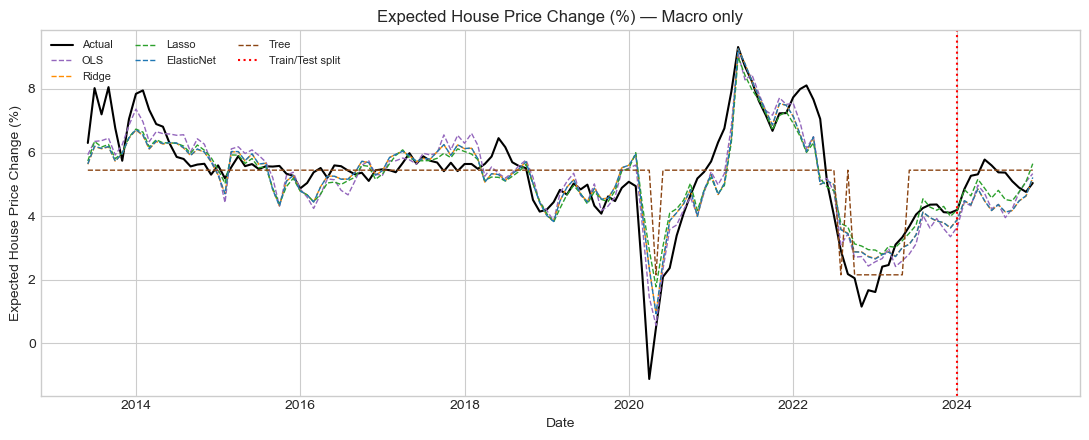

In [42]:
plot_predictions(res, train, test, target, num, cat, "Macro only")

OLS, Lasso, Ridge and ElasticNet track the gradual decline from 2013 to 2019 and partially capture the 2020 COVID collapse, though they substantially underestimate the trough which passed below 0%. The Decision Tree produces a near-constant prediction just below 6%, but partially captures the 2020 shock and the 2021–2022 surge.


── prob_unrate_up (Macro only) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=3.793e+05                      CV MSE=491.1653
  Lasso       alpha=0.4833                         CV MSE=491.9245
  ElasticNet  alpha=0.4833, l1_ratio=0.25          CV MSE=490.9726
  Tree        max_depth=2                          CV MSE=499.6141


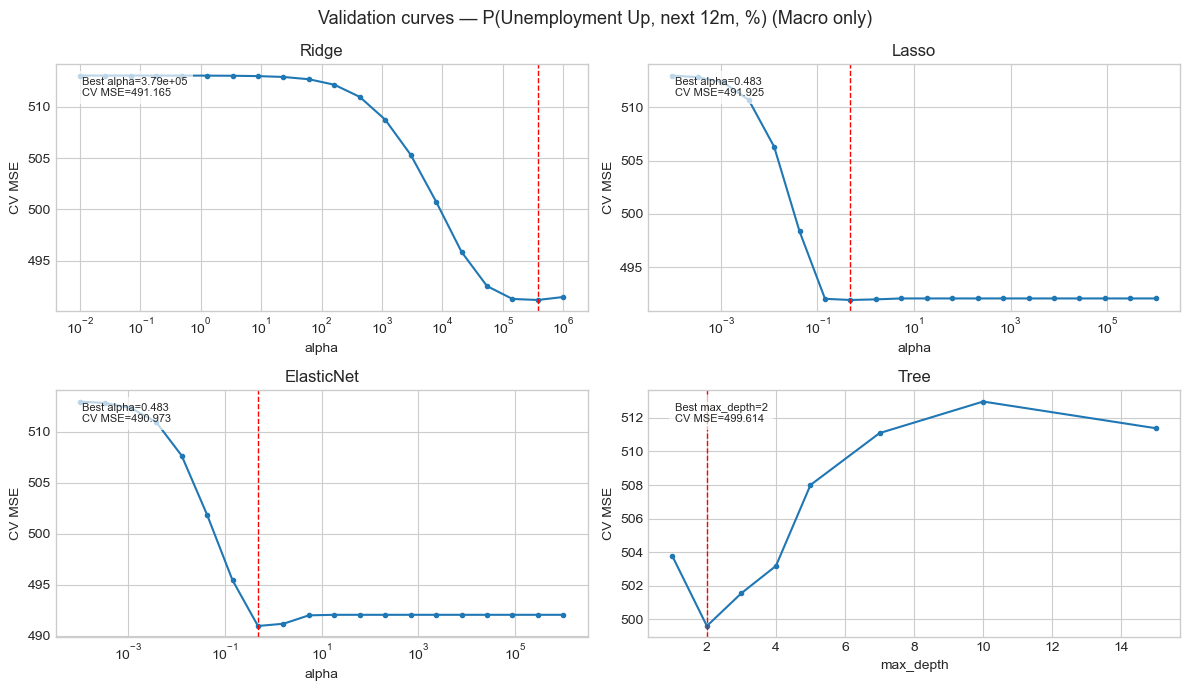

In [43]:
# Probability of unemployment rate up target   
target = "prob_unrate_up"

# Run CV, store results and compute test metrics for the "Macro only" feature set
res = run_cv_for_target(train, target, num, cat, "Macro only")
macro_only_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro only"))

Ridge selects an extremely large α (≈ 379,000), with the validation curve monotonically decreasing across the search range, suggesting the model shrinks all coefficients to near zero and predicts close to the mean. Lasso selects α ≈ 0.483 with a flat plateau for large α values, indicating that a sparse solution with few active features is sufficient. ElasticNet selects the same α with l1_ratio=0.25, combining both penalties. The Decision Tree prefers depth 2, with CV MSE rising sharply for deeper trees.

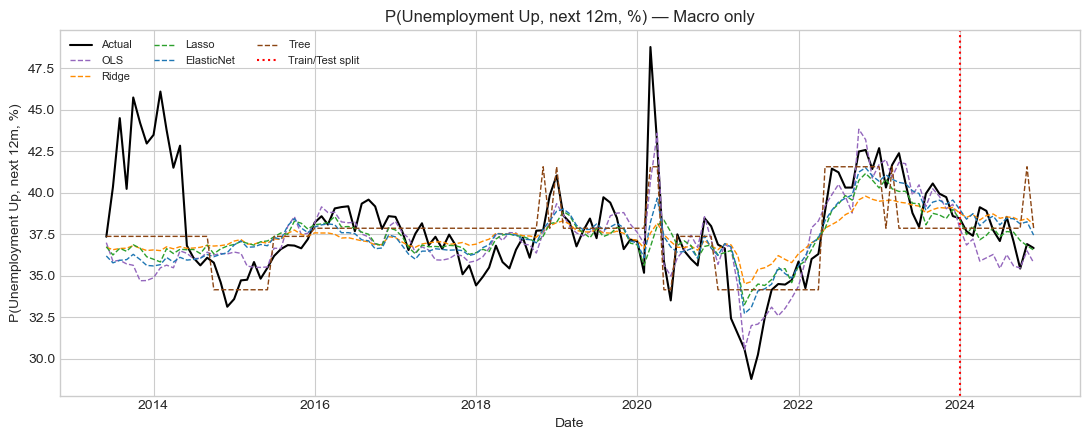

In [44]:
plot_predictions(res, train, test, target, num, cat, "Macro only")

All models struggle to track prob_unrate_up with macro features only. Linear models predict close to the sample mean throughout, missing the elevated readings in 2013–2014 and underestimating the sharp COVID-19 spike in early 2020. The Decision Tree captures some step-like variation but similarly misses the 2020 spike.


── prob_stocks_up (Macro only) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=1.438e+05                      CV MSE=491.2109
  Lasso       alpha=0.1438                         CV MSE=492.7156
  ElasticNet  alpha=1.624, l1_ratio=0.01           CV MSE=491.2610
  Tree        max_depth=1                          CV MSE=492.9585


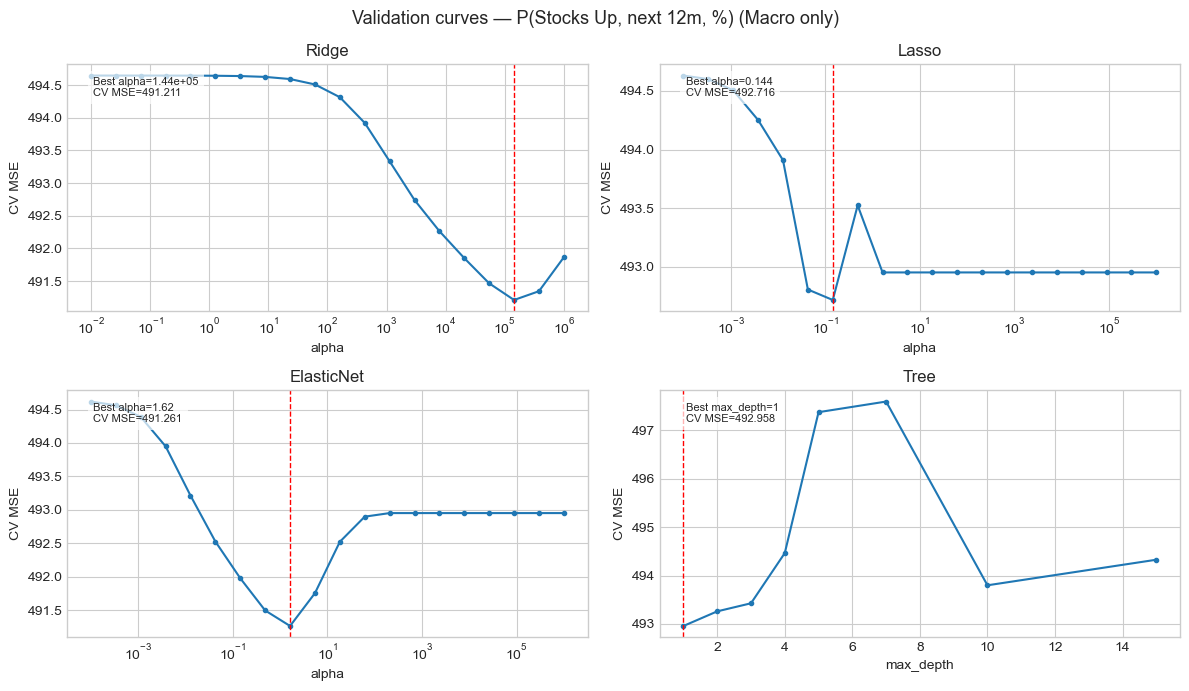

In [45]:
# Probability of stocks up target
target = "prob_stocks_up"

# Run CV, store results and compute test metrics for the "Macro only" feature set
res = run_cv_for_target(train, target, num, cat, "Macro only")
macro_only_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro only"))

Ridge selects a large α (≈ 144,000), consistent with the pattern for prob_unrate_up, where heavy shrinkage is optimal when macro signal is weak. Lasso selects α ≈ 0.144, while ElasticNet selects α ≈ 1.62 with l1_ratio=0.01, effectively behaving as Ridge for this target. The Decision Tree prefers depth 1 with a highly non-monotonic validation curve for deeper trees. CV MSE differences across models are small (491- 493), confirming that no model has a meaningful advantage with macro features only.

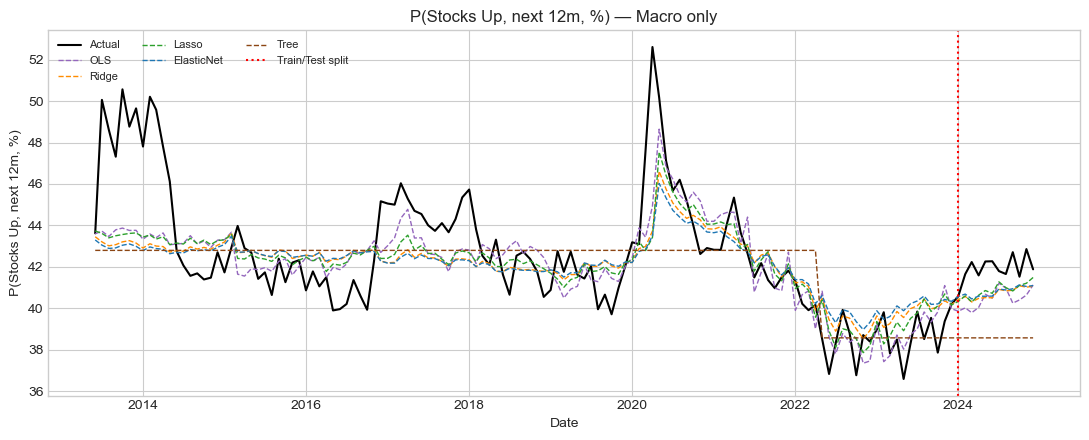

In [46]:
plot_predictions(res, train, test, target, num, cat, "Macro only")

All models manage to track the long-run downward trend in stock market optimism from ~50% in 2013 to ~38% by 2022–2023, but fail to capture some short-term spikes. Linear models produce relatively flat predictions around the mean throughout, though OLS, Lasso and ElasticNet partially capture the 2020 COVID spike. The Decision Tree predicts a near-constant ~43% with a step down from late 2022. 

### 5.2 - Macro/Finance Predictors + SCE Individual Predictors


── infl_1y (Macro + SCE) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=2976                           CV MSE=65.2556
  Lasso       alpha=0.01274                        CV MSE=65.1173
  ElasticNet  alpha=0.01274, l1_ratio=1            CV MSE=65.1173
  Tree        max_depth=5                          CV MSE=66.9706


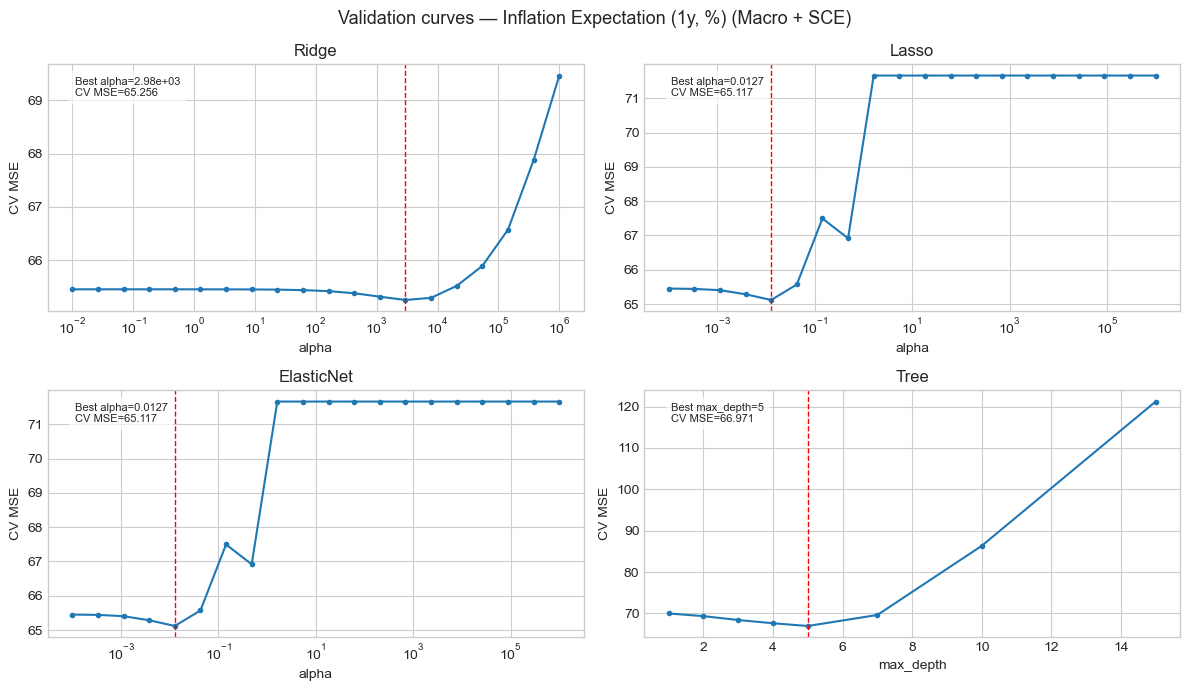

In [47]:
# Step 2: Macro + SCE
# New feature set
num, cat = FEATURE_SETS["Macro + SCE"]

# Initialize result storing structure for Macro + SCE
macro_sce_results = {}

# Inflation expectation (1 year) target
target = "infl_1y"

# Run CV, store results and compute test metrics for the "Macro + SCE" feature set
res = run_cv_for_target(train, target, num, cat, "Macro + SCE")
macro_sce_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro + SCE"))

Adding SCE variables reduces CV MSE from ~70.3 to ~65.3 (Ridge) and ~70.2 to ~65.1 (Lasso), a reduction of about 5 MSE units. Ridge retains the same optimal α (≈ 2,980), suggesting the SCE variables do not change the regularization structure much. Lasso and ElasticNet both select α ≈ 0.013 with l1_ratio=1, making them identical for this target. The Decision Tree now prefers depth 5 compared to depth 2 in the macro-only case, reflecting that the additional SCE features provide more useful splits, though the steep and continuous rise in CV MSE beyond depth 5 indicates clear overfitting risk.

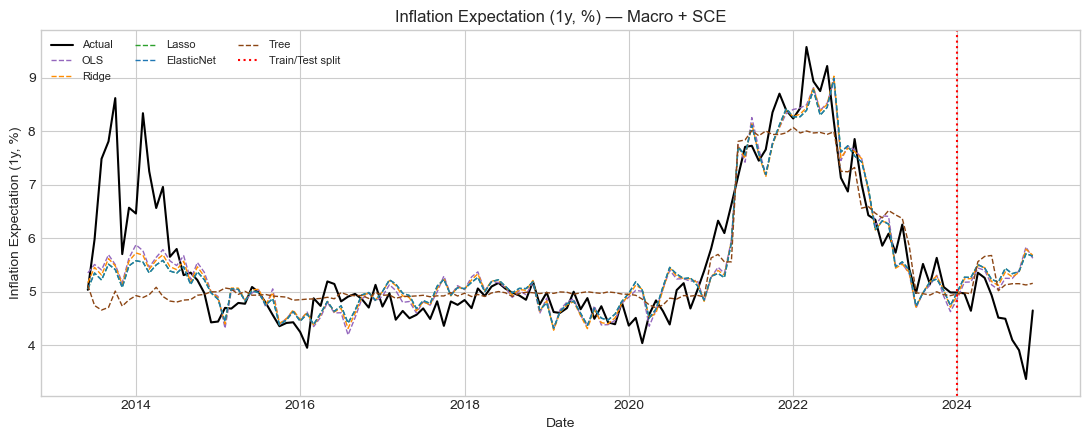

In [48]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE")

During the training period, OLS, Lasso and ElasticNet track the historical pattern closely in both feature sets and capture the 2021–2022 inflation surge well, but neither feature set captures the sharp spikes in 2013–2014. The Decision Tree produces a step function pattern in both cases, though it follows the trend somewhat better with SCE features. In the test period (2024), all models fail to capture the sharp decline in inflation expectations, as the actual series falls to about 3.5% while all models predict around 5% or above.


── house_price_change (Macro + SCE) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=2.069e+04                      CV MSE=55.5864
  Lasso       alpha=0.04281                        CV MSE=55.9974
  ElasticNet  alpha=0.1438, l1_ratio=0.01          CV MSE=55.5736
  Tree        max_depth=3                          CV MSE=58.6121


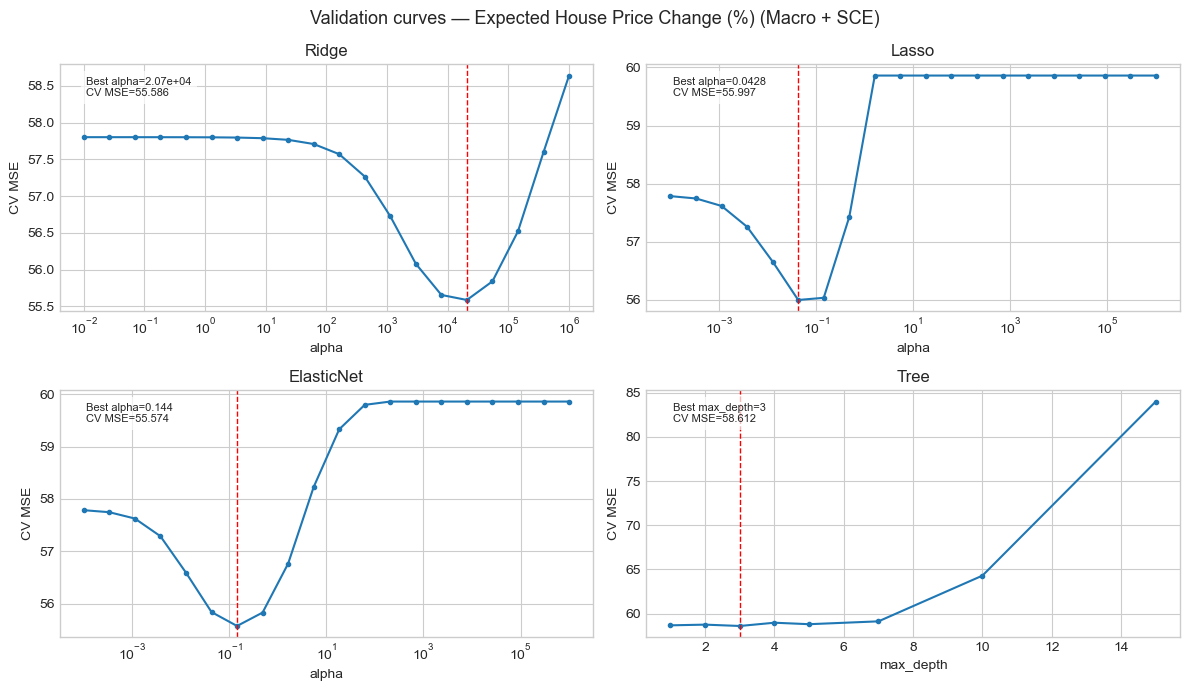

In [49]:
# House price change expectation target
target = "house_price_change"

# Run CV, store results and compute test metrics for the "Macro + SCE" feature set
res = run_cv_for_target(train, target, num, cat, "Macro + SCE")
macro_sce_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro + SCE"))

Adding SCE variables reduces CV MSE by about 2.5 MSE units across linear models, from ~58.2 to ~55.6 (Ridge) and ~58.6 to ~56.0 (Lasso). Ridge retains the same large α (≈ 20,700). Lasso selects a smaller α (≈ 0.043) compared to macro-only (0.144), suggesting the additional SCE features require less aggressive shrinkage. ElasticNet selects α ≈ 0.144 with l1_ratio=0.01, again behaving as Ridge. The Decision Tree now prefers depth 3, though CV MSE rises steeply beyond this, indicating strong overfitting risk.

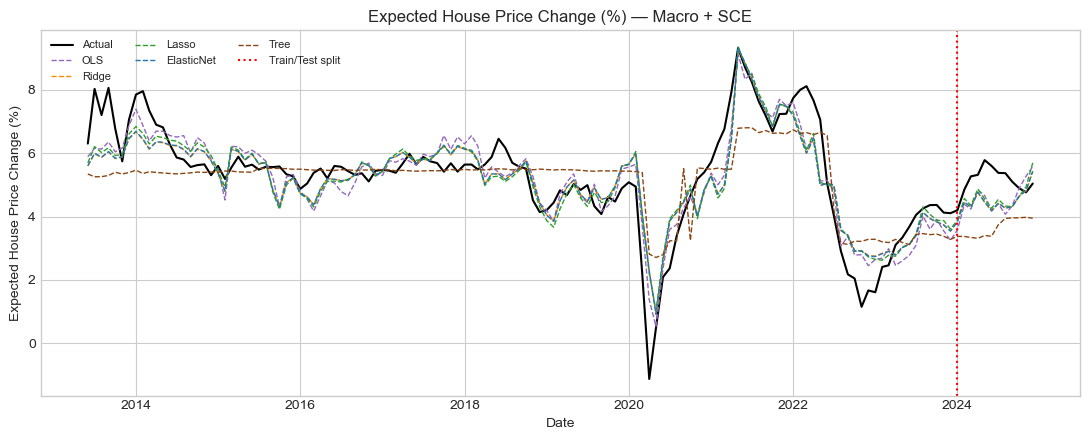

In [50]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE")

During the training period, OLS, Lasso and ElasticNet track the historical pattern reasonably well in both feature sets, capturing the 2020 decline and 2021–2022 surge, though neither fully reaches the sharp trough. The Decision Tree is near-constant in the macro-only case but shows more variation with SCE features. In the test period (2024), OLS, Lasso and ElasticNet track the actual series reasonably well in both feature sets, with the Macro + SCE versions showing a slight improvement. The Decision Tree remains relatively flat in both cases, missing much of the variation.


── prob_unrate_up (Macro + SCE) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=1.438e+05                      CV MSE=489.3213
  Lasso       alpha=0.4833                         CV MSE=490.6624
  ElasticNet  alpha=0.4833, l1_ratio=0.25          CV MSE=489.1502
  Tree        max_depth=3                          CV MSE=502.1113


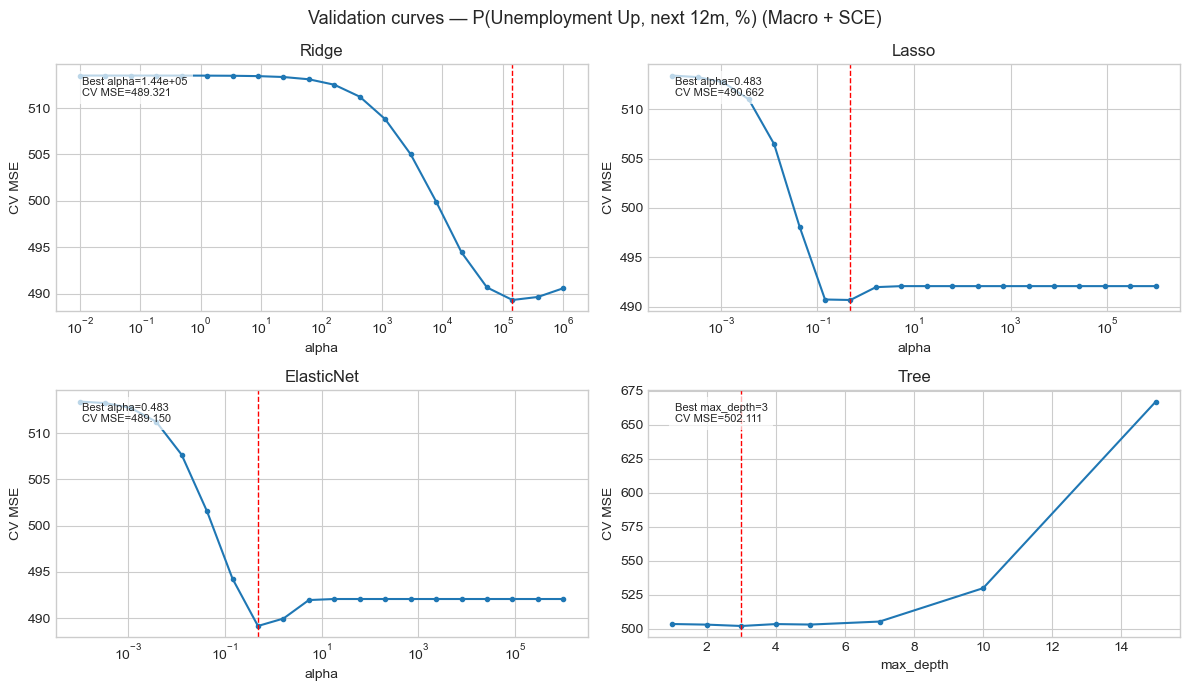

In [51]:
# Probability of unemployment rate up target
target = "prob_unrate_up"

# Run CV, store results and compute test metrics for the "Macro + SCE" feature set
res = run_cv_for_target(train, target, num, cat, "Macro + SCE")
macro_sce_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro + SCE"))

Adding SCE variables reduces CV MSE by about 2 MSE units for Ridge and ElasticNet, from ~491 to ~489, suggesting SCE variables add limited predictive power for this target beyond what macro variables already capture. Ridge retains a very large α (≈ 144,000). Lasso and ElasticNet both select α ≈ 0.483, consistent with the macro-only case. The Decision Tree now prefers depth 3, but CV MSE rises steeply beyond this, reaching ~670 at depth 15, indicating severe overfitting when SCE features are included.

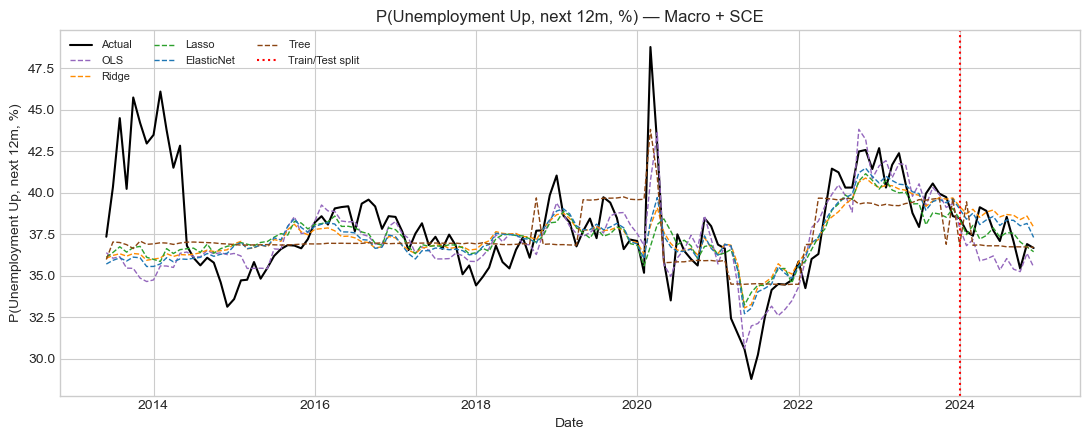

In [52]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE")

During the training period, all models track the general level of the series reasonably well in both feature sets, but fail to capture the elevated readings in 2013–2014 and the sharp COVID 19 spike in 2020. The Decision Tree produces a clear step function pattern in the macro only case but is considerably smoother with SCE features. In the test period (2024), the Macro + SCE version tracks the actual series more closely, most notably for OLS, which produces an upward spike in the macro only case that is absent in the actual series, while the Macro + SCE version remains more stable and closer to the actual values.


── prob_stocks_up (Macro + SCE) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=7848                           CV MSE=456.9652
  Lasso       alpha=0.1438                         CV MSE=456.9343
  ElasticNet  alpha=0.1438, l1_ratio=1             CV MSE=456.9343
  Tree        max_depth=4                          CV MSE=460.6942


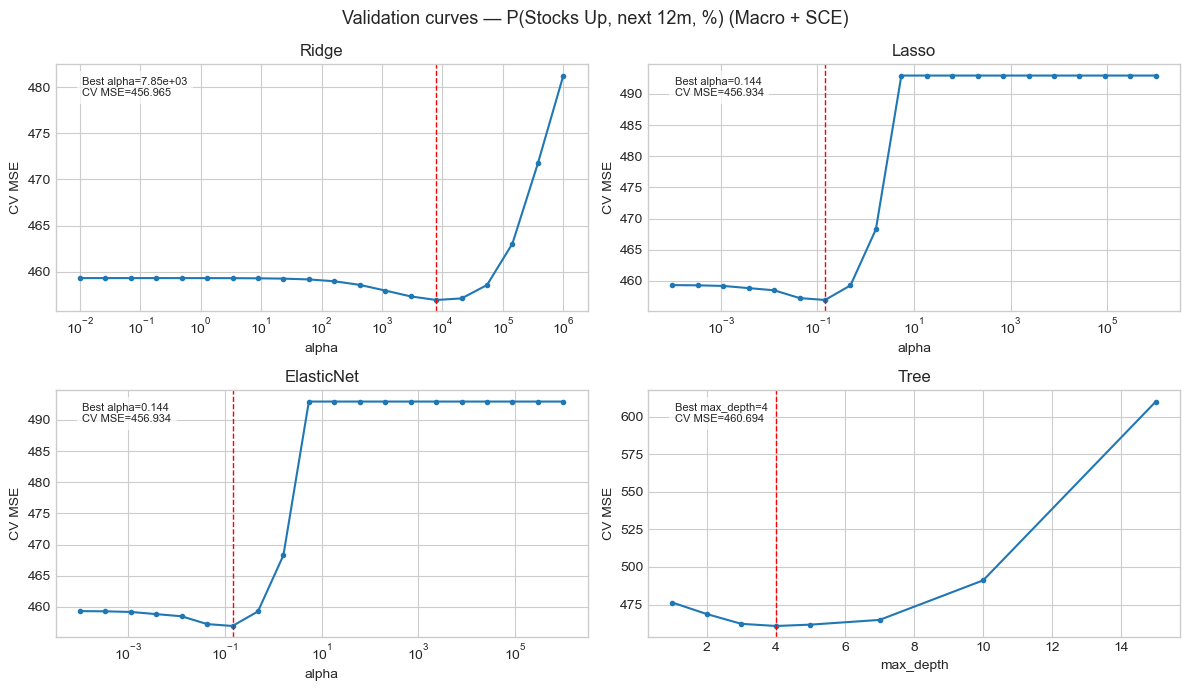

In [53]:
# Probability of stocks up target
target = "prob_stocks_up"

# Run CV, store results and compute test metrics for the "Macro + SCE" feature set
res = run_cv_for_target(train, target, num, cat, "Macro + SCE")
macro_sce_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro + SCE"))

Adding SCE variables produces the largest CV MSE reduction of all four targets, from ~491 to ~457. Ridge now selects a much smaller α (≈ 7,848) compared to macro-only (≈ 144,000), confirming that the SCE variables provide genuine predictive signal that reduces the need for heavy regularization. Lasso and ElasticNet both select α ≈ 0.144 with l1_ratio=1, collapsing to pure Lasso. The Decision Tree prefers depth 4, with CV MSE rising steeply beyond depth 7, indicating clear overfitting risk.

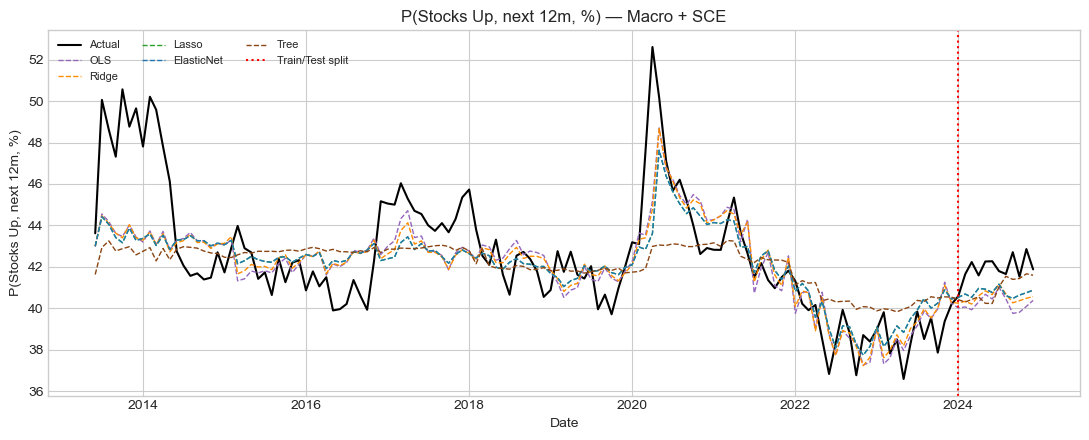

In [54]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE")

During the training period, OLS, Lasso, ElasticNet and Ridge track the general trend reasonably well in both feature sets, but only partially capture the COVID 19 spike in 2020, as the macro only models reach around ~45% while the actual series peaks at ~52%. With SCE features, these models come considerably closer to the actual peak. The Decision Tree is essentially a flat line in the macro only case, while with SCE features it follows the general trend more closely, though it still produces a flatter and less responsive prediction than the linear models. In the test period (2024), the Macro + SCE models track the actual series more tightly with predictions nearly overlapping the actual values, while the macro only models show slightly more spread.

In [55]:
# Display test metrics in a pivot table for easy comparison across models, targets, and feature sets
results_df_exp = pd.concat(all_metrics, ignore_index=True)
results_pivot_exp = results_df_exp.pivot_table(
    index=['target', 'feature_set'],
    columns='model',
    values=['RMSE', 'R2']
).round(4).T

display(results_pivot_exp)

target          house_price_change                infl_1y             \
feature_set            Macro + SCE Macro only Macro + SCE Macro only   
     model                                                             
R2   ElasticNet             0.0432    -0.0078      0.0497    -0.0053   
     Lasso                  0.0444    -0.0025      0.0497    -0.0053   
     OLS                    0.0432    -0.0077      0.0501    -0.0053   
     Ridge                  0.0431    -0.0079      0.0496    -0.0056   
     Tree                  -0.0142    -0.0014      0.0407    -0.0003   
RMSE ElasticNet             8.2553     8.4728      8.9990     9.2557   
     Lasso                  8.2504     8.4505      8.9990     9.2557   
     OLS                    8.2555     8.4721      8.9970     9.2558   
     Ridge                  8.2558     8.4730      8.9994     9.2571   
     Tree                   8.4996     8.4457      9.0415     9.2328   

target          prob_stocks_up            prob_unrate_up             
feature_set        Macro + SCE Macro only    Macro + SCE Macro only  
     model                                                           
R2   ElasticNet         0.1185    -0.0024         0.0297    -0.0008  
     Lasso              0.1185    -0.0021         0.0241     0.0003  
     OLS                0.1187    -0.0042         0.0353    -0.0035  
     Ridge              0.1181    -0.0027         0.0247    -0.0014  
     Tree               0.1148    -0.0210         0.0266    -0.0033  
RMSE ElasticNet        21.5527    22.9826        21.9871    22.3307  
     Lasso             21.5527    22.9795        22.0508    22.3183  
     OLS               21.5498    23.0038        21.9240    22.3601  
     Ridge             21.5572    22.9864        22.0444    22.3365  
     Tree              21.5972    23.1955        22.0226    22.3584

Including individual-level SCE variables consistently improves both R² and RMSE across all four targets and all models, with one exception: the Decision Tree for house_price_change performs slightly worse with SCE features (R² = -0.014 vs -0.001), likely due to overfitting. However, these improvements are very small - implying that adding SCE variables adds very little predictive power and the vast majority of variation remains unexplained.

The improvement is largest for prob_stocks_up (R² from negative to 0.119 with OLS), consistent with this target having the strongest correlations with demographic variables in Part 4. For prob_unrate_up, the improvement is modest (R² ≈ 0.035), consistent with the weak SCE correlations observed in Part 4. Absolute R² values remain low across all targets, indicating that individual-level variation in expectations is largely unexplained by macro variables and stable demographic characteristics alone.

In [56]:
# Summarize best models by R² and RMSE
summary_exp = []
for target in TARGETS:
    target_df = results_df_exp[results_df_exp["target"] == target]
    best_r2_row = target_df.loc[target_df["R2"].idxmax()]
    best_rmse_row = target_df.loc[target_df["RMSE"].idxmin()]
    summary_exp.append({
        "target": target,
        "best_R2_model": best_r2_row["model"],
        "best_R2": best_r2_row["R2"],
        "best_R2_feature_set": best_r2_row["feature_set"],
        "best_RMSE_model": best_rmse_row["model"],
        "best_RMSE": best_rmse_row["RMSE"],
        "best_RMSE_feature_set": best_rmse_row["feature_set"],
    })

summary_df_exp = pd.DataFrame(summary_exp)
display(summary_df_exp)

,target,best_R2_model,best_R2,best_R2_feature_set,best_RMSE_model,best_RMSE,best_RMSE_feature_set
0,infl_1y,OLS,0.050128,Macro + SCE,OLS,8.997028,Macro + SCE
1,house_price_change,Lasso,0.044370,Macro + SCE,Lasso,8.250429,Macro + SCE
2,prob_unrate_up,OLS,0.035290,Macro + SCE,OLS,21.923992,Macro + SCE
3,prob_stocks_up,OLS,0.118698,Macro + SCE,OLS,21.549830,Macro + SCE


The best-performing feature set is consistently Macro + SCE across all targets and metrics. Among models, OLS performs best or near-best for three of four targets. Differences between OLS and regularized linear models are negligible, which suggests that with our modest number of predictors and large sample size, OLS is already stable. This does not rule out non-linear relationships, but more complex models (tree) also fail to improve out-of-sample performance.

## Part 6 - Predict Optimism Indicators (Classification)

Part 6 repeats the analysis from Part 5 using the three binary optimism indicators as targets. Since these are classification tasks, we use Logistic Regression, Random Forest and Histogram-based Gradient Boosting, with the latter included as an additional model well suited for large tabular datasets. Hyperparameters are selected by maximising cross‑validated ROC‑AUC, which is more informative than accuracy under class imbalance. All models use class_weight='balanced' to avoid predicting the majority class for all observations. Without this, initial experiments showed all models predicting class 1 for basically every observation. The reweighting of classes also tends to pull predicted probabilities toward the middle of the [0,1] range when the signal in the features is weak, which helps explain why the predicted optimism shares often cluster around one half. We report Accuracy, Precision, Recall, F1 and ROC‑AUC on both the training and test samples.

In [57]:
# Correlations for predictor choice - Macro/Finance
html_tables = []
for col in OPTIMISM_COLS:
    corr = (
        sce_data[MACRO_COLS]
        .corrwith(sce_data[col])
        .rename('correlation')
        .to_frame()
        .assign(abs_corr=lambda df: df['correlation'].abs())
        .sort_values('abs_corr', ascending=False)
        .drop(columns='abs_corr')
    )
    styled = (corr.style
                  .background_gradient(cmap='RdBu', vmin=-0.15, vmax=0.20)
                  .format("{:.2f}")
                  .set_caption(f"Correlations with {col}"))
    html_tables.append(styled.to_html())

# Wrap in a flex row and display once
display(HTML(
    '<div style="display:flex; gap:20px; align-items:flex-start;">'
    + ''.join(f'<div>{t}</div>' for t in html_tables)
    + '</div>'
))

,correlation
sp500_chg12m,0.07
mortgage_30y,-0.06
federal_funds,-0.05
federal_funds_chg12m,-0.05
10y_yield,-0.05
unemployment,0.05
mortgage_30y_chg12m,-0.04
wti_crude_oil_chg12m,0.04
usd_index,-0.04
usd_index_chg12m,-0.04


In [58]:
# Correlations for predictor choice - SCE predictors
html_tables = []
for col in OPTIMISM_COLS:
    corr = (
        sce_data[COLS_FIRST_WAVE + COLS_INDIVIDUAL]
        .corrwith(sce_data[col])
        .rename('correlation')
        .to_frame()
        .assign(abs_corr=lambda df: df['correlation'].abs())
        .sort_values('abs_corr', ascending=False)
        .drop(columns='abs_corr')
    )
    styled = (corr.style
                  .background_gradient(cmap='RdBu', vmin=-0.15, vmax=0.20)
                  .format("{:.2f}")
                  .set_caption(f"Correlations with {col}"))
    html_tables.append(styled.to_html())

# Wrap in a flex row and display once
display(HTML(
    '<div style="display:flex; gap:20px; align-items:flex-start;">'
    + ''.join(f'<div>{t}</div>' for t in html_tables)
    + '</div>'
))

,correlation
num_lit_q2_correct,-0.07
num_lit_q3_correct,-0.05
educ,-0.05
num_lit_q6_correct,-0.05
female,0.04
age_init,0.03
num_lit_q5_correct,-0.03
num_lit_q1_correct,-0.03
hh_inc_bin_rank,-0.03
hispanic,0.02


As was the case with the expectation targets in Part 5, correlations between potential predictors and the optimism indicators are modest. Macro/finance variables correlate most strongly with house-price optimism; SCE variables correlate most meaningfully with stock-market optimism and only weakly with the other two targets. We should not expect the models to achieve strong out-of-sample performance regardless of predictor choice, but we focus on the variables that carry the clearest signal.

For macro/finance predictors we include unemployment, vix, and mortgage_30y as levels, and cpi, house_price_idx, sp500, federal_funds, and mortgage_30y as 12-month changes. The levels we keep are rate/volatility series that should be broadly stationary within the sample; the series we enter as 12-month changes (CPI, house-price index, S&P 500, fed-funds) trend monotonically and their raw levels would mostly capture a time trend that cannot extrapolate to the 2024 test window. The top level-correlations for house-price optimism (cpi, house_price_idx, real_gdp, usd_index at ρ ≈ −0.20) are driven almost entirely by this common trend and we therefore exclude them in favour of their stationary change counterparts.

For SCE predictors we include num_lit_q2_correct, num_lit_q3_correct, female, black, hh_inc_bin_rank, and age_init, together with educ one-hot encoded. This mirrors the logic in Part 5 as financial literacy, gender, education, and income rank are the strongest individual-level predictors for stock optimism, with age_init added because it is the only SCE variable with a non-trivial correlation for house-price optimism.

In [59]:
# Feature sets for Part 6 - Chosen based on Correlation analysis and theoretical considerations
NUM_MACRO_OPT = [
    # stationary levels
    "unemployment", "vix", "mortgage_30y",
    # 12m changes (avoids non-stationary-level trend artefacts)
    "cpi_chg12m", "house_price_idx_chg12m", "sp500_chg12m",
    "federal_funds_chg12m", "mortgage_30y_chg12m",
]

# SCE variables that don't need encoding.
NUM_SCE_OPT = [
    "num_lit_q2_correct", "num_lit_q3_correct",
    "female", "black",
    "hh_inc_bin_rank", "age_init",
]

# SCE Variable that needs encoding (education levels are categorical and not ordinal, so we will one-hot encode them)
ENCODE_SCE_OPT = ["educ"]

# Combine feature sets into a dictionary for easy access in modeling and plotting
FEATURE_SETS_OPT = {
    "Macro only":  (NUM_MACRO_OPT,            []),
    "Macro + SCE": (NUM_MACRO_OPT + NUM_SCE_OPT,  ENCODE_SCE_OPT)
}

# Targets and labels for the "Optimism" models
OPT_TARGETS = OPTIMISM_COLS
OPT_TARGET_LABELS = {
    "optimist_unrate":      "Unemployment Optimists (prob < 50%)",
    "optimist_stocks":      "Stock Market Optimists (prob > 50%)",
    "optimist_house_price": "House Price Optimists (change > 0%)",
}

In [60]:
# Configuration for the "Optimism" models (Overwrites the previous MODELS dict with models more appropriate for classification tasks)
MODELS = {
    # Logistic regression
    "LogisticRegression": {
        "estimator": LogisticRegression(random_state=0, max_iter=5000, class_weight="balanced"),
        "param_grid": {"estimator__C": np.logspace(-4, 4, 20)},
        "scale": True,
        "param_name": "estimator__C",
        "log_x": True,
    },
    # Random forest classifier
    "RandomForest": {
        "estimator": RandomForestClassifier(random_state=0, class_weight="balanced"),
        "param_grid": {"estimator__max_depth": [1, 2, 3, 5, 7, 10]},
        "scale": False,
        "param_name": "estimator__max_depth",
        "log_x": False,
    },
    # Histogram-based gradient boosting classifier
    "HistGradientBoosting": {
        "estimator": HistGradientBoostingClassifier(random_state=0, class_weight="balanced"),
        "param_grid": {"estimator__max_depth": [1, 2, 3, 5, 7, 10]},
        "scale": False,
        "param_name": "estimator__max_depth",
        "log_x": False,
    },
}

# Colors for the "Optimism" models (Overwrites the previous COLORS dict with a new set of colors for the classification models)
COLORS = {
    "LogisticRegression": "tab:blue",
    "RandomForest": "tab:green",
    "HistGradientBoosting": "tab:orange",
}

In [61]:
# Compute test metrics for classification models - Part 6 specific (Accuracy, Precision, Recall, F1, ROC-AUC)
def test_metrics_clf(results, sample, target, num_cols, cat_cols, feature_set_name):
    """
    Classification metrics per model on the test sample.

    Parameters
    ----------
    results : dict
        Mapping model_name -> {"pipeline": fitted_pipeline, ...}
    sample : pd.DataFrame
        Test or Training DataFrame containing features and the binary target.
    target : str
        Name of the binary target column (0/1).
    num_cols, cat_cols : list[str]
        Lists of numeric and categorical feature names.
    feature_set_name : str
        Label for the feature set (e.g. "Macro", "Macro + SCE").

    Returns
    -------
    pd.DataFrame
        One row per model with Accuracy, Precision, Recall, F1, ROC-AUC.
        ROC-AUC is NaN if the model does not support predict_proba.
    """
    # Combine numeric and categorical columns into a single list of features for prediction
    features = num_cols + cat_cols

    # Prepare the feature matrix and true labels from the test sample for evaluation
    X_te = sample[features]
    y_te = sample[target].values

    rows = []

    # Loop through models, predict through pipeline, compute classification metrics against true test labels
    for model_name, mr in results.items():
        pipe = mr["pipeline"]

        # hard predictions for accuracy / F1
        y_pred = pipe.predict(X_te)

        # probabilities for ROC-AUC if available
        roc_auc = np.nan
        if hasattr(pipe, "predict_proba"):
            y_prob = pipe.predict_proba(X_te)[:, 1]
            roc_auc = roc_auc_score(y_te, y_prob)

        # Append the results for this model to the rows list
        rows.append({
            "feature_set": feature_set_name,
            "target": target,
            "model": model_name,
            "Accuracy":  accuracy_score(y_te, y_pred),
            "Precision": precision_score(y_te, y_pred, zero_division=0),
            "Recall":    recall_score(y_te, y_pred, zero_division=0),
            "F1":        f1_score(y_te, y_pred, zero_division=0),
            "ROC-AUC":   roc_auc,
        })

    return pd.DataFrame(rows)

### 6.1 - Classification on Macro/Finance Variables


── optimist_unrate (Macro) ──
  LogisticRegression C=0.0001                             CV ROC-AUC=0.5311
  RandomForest max_depth=2                          CV ROC-AUC=0.5332
  HistGradientBoosting max_depth=1                          CV ROC-AUC=0.5274


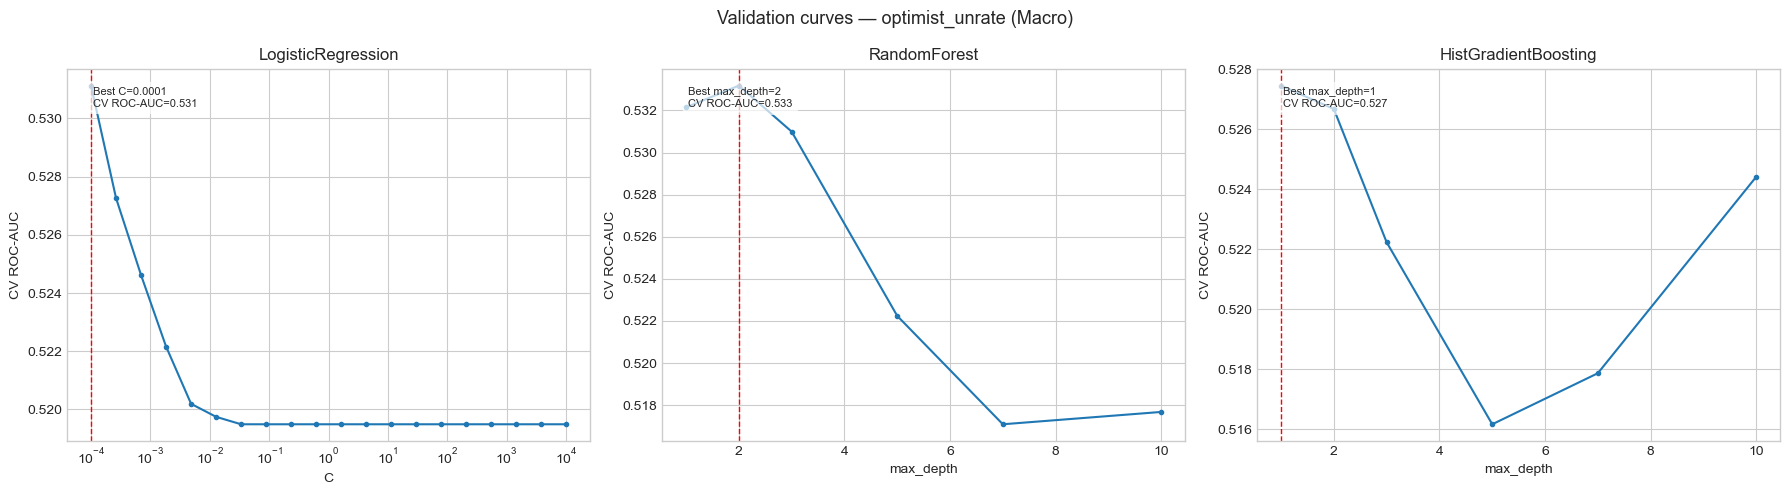

In [62]:
# Initialize features and result storing structures - With separate lists for train/test metrics
num, cat = FEATURE_SETS_OPT["Macro only"]
clf_test_metrics = []
clf_train_metrics = []

# Unemployment rate optimists target
target = "optimist_unrate"

# Run CV, store results and compute test metrics for the "Macro only" feature set
res = run_cv_for_target(train, target, num, cat, "Macro", PART_6=True)
clf_test_metrics.append(test_metrics_clf(res, test, target, num, cat, "Macro"))
clf_train_metrics.append(test_metrics_clf(res, train, target, num, cat, "Macro"))

All three models achieve CV ROC-AUC of about 0.53, only slightly above the 0.50 benchmark of a random classifier. LogisticRegression selects a very small C (≈ 0.0001), implying strong regularization and suggesting that the macro features carry little signal. RandomForest achieves its best performance at a shallow tree (max_depth = 2) before performance deteriorates for deeper trees, while HistGradientBoosting prefers max_depth = 1. The very narrow range of ROC-AUC values across the hyperparameter grids indicates that macro variables have very limited discriminatory power for this target.

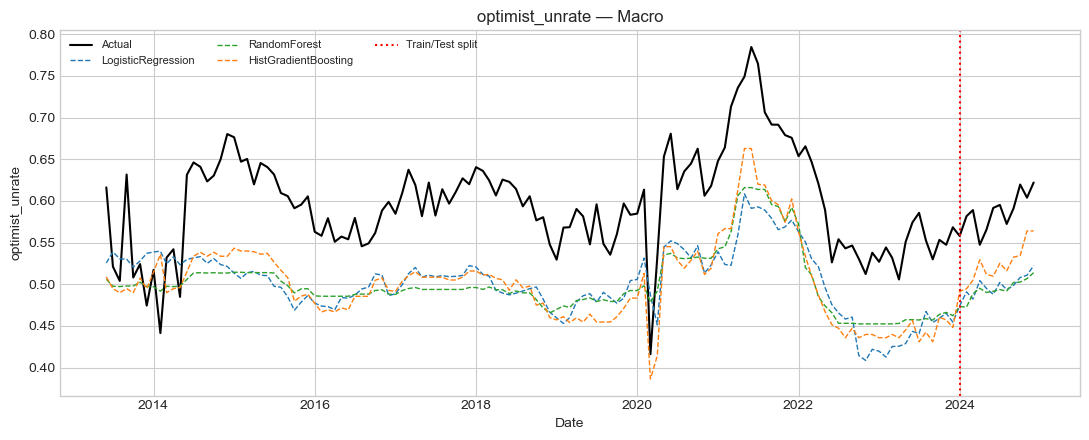

In [63]:
plot_predictions(res, train, test, target, num, cat, "Macro", split_date="2024-01-01")

With macro features only, the predicted share of optimists stays in a relatively narrow band, whereas the actual series shows much larger swings. Weak signal in the macro variables, combined with class_weight='balanced', pulls predicted probabilities toward the middle of the 0,1 range. The models track some broad movements but systematically underestimate optimism, including the sharp rise around 2021–2022. In the test period (2024), predictions do increase with the recovery in the actual series, but remain below the observed optimism rates.


── optimist_stocks (Macro) ──
  LogisticRegression C=0.0002637                          CV ROC-AUC=0.4795
  RandomForest max_depth=7                          CV ROC-AUC=0.4682
  HistGradientBoosting max_depth=1                          CV ROC-AUC=0.4751


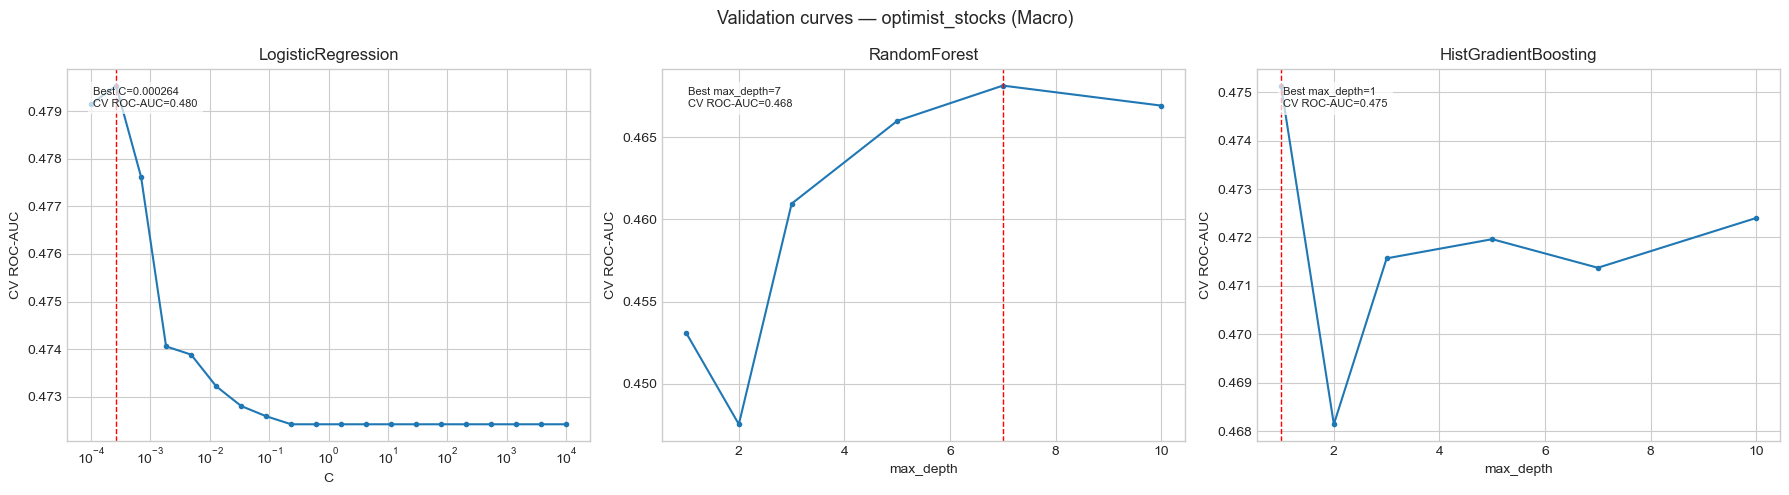

In [64]:
# Stock market optimists target
target = "optimist_stocks"

# Run CV, store results and compute test metrics for the "Macro only" feature set
res = run_cv_for_target(train, target, num, cat, "Macro", PART_6=True)
clf_test_metrics.append(test_metrics_clf(res, test, target, num, cat, "Macro"))
clf_train_metrics.append(test_metrics_clf(res, train, target, num, cat, "Macro"))

CV ROC‑AUC values are around 0.47–0.48 for all three models, essentially indistinguishable from the 0.50 benchmark of a random classifier. LogisticRegression selects a very small C, implying strong regularization and suggesting that the macro features contain little usable signal. For RandomForest, performance increases only slightly with depth and then levels off, while HistGradientBoosting achieves its best ROC‑AUC at the minimal depth of 1. Overall, the validation curves indicate that macro variables alone have almost no meaningful discriminatory power for stock market optimism.

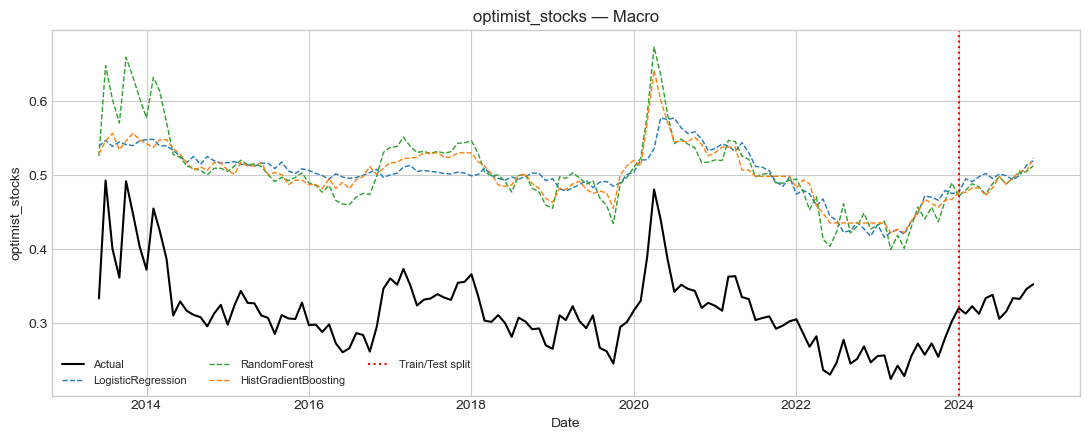

In [65]:
plot_predictions(res, train, test, target, num, cat, "Macro", split_date="2024-01-01")

With macro features only, the models capture some of the broad movements in stock market optimism but systematically predict higher optimism rates than observed in the data. This is consistent with macro variables providing very little usable signal for this target, so the classifiers revert to probabilities clustered around one half. In the test period (2024), the actual series recovers and trends upwards from clearly below one half, while the model-based predictions remain close to 50%.


── optimist_house_price (Macro) ──
  LogisticRegression C=0.0001                             CV ROC-AUC=0.2925
  RandomForest max_depth=1                          CV ROC-AUC=0.2931
  HistGradientBoosting max_depth=2                          CV ROC-AUC=0.1934


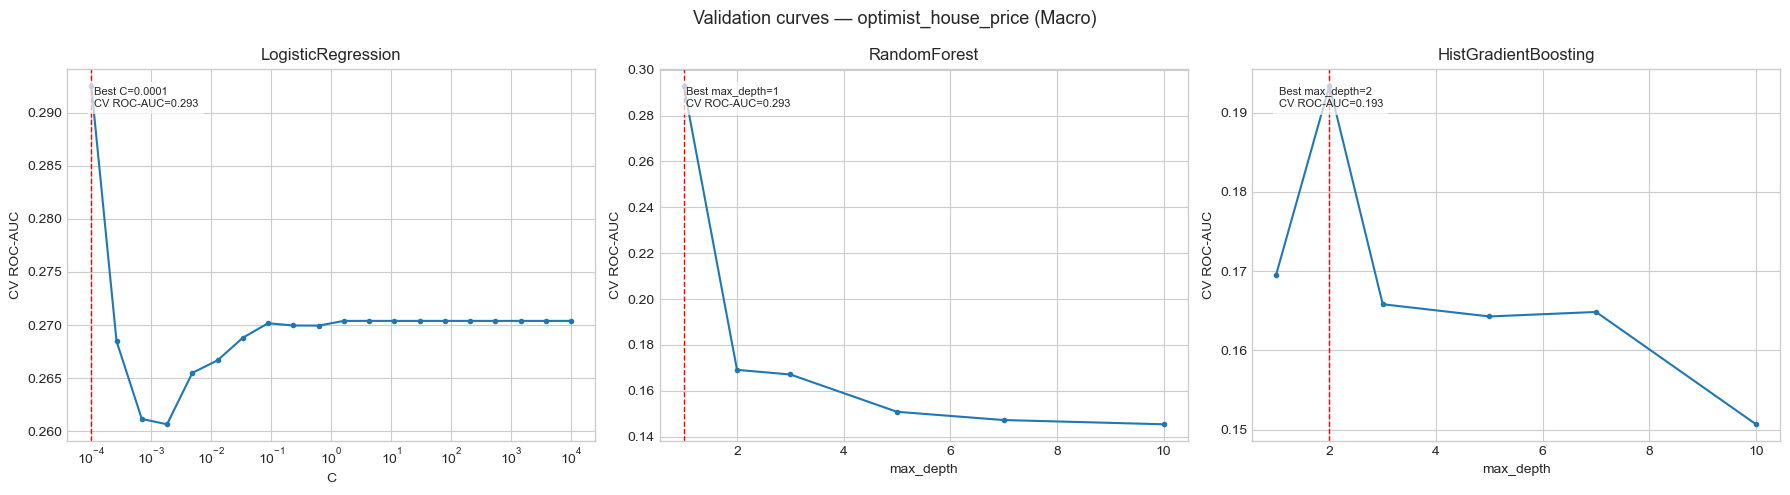

In [66]:
# House price optimists target
target = "optimist_house_price"

# Run CV, store results and compute test metrics for the "Macro only" feature set
res = run_cv_for_target(train, target, num, cat, "Macro", PART_6=True)
clf_test_metrics.append(test_metrics_clf(res, test, target, num, cat, "Macro"))
clf_train_metrics.append(test_metrics_clf(res, train, target, num, cat, "Macro"))

All three models achieve CV ROC‑AUC well below 0.50, meaning they rank positive and negative cases worse than a random classifier. With class_weight='balanced', always predicting the majority class is heavily penalised, so in the absence of useful signal the models are pushed toward probability patterns that actually reduce ROC‑AUC. The validation curves decline monotonically (or remain low) as regularization is relaxed or trees become deeper, indicating that additional complexity mainly fits noise and further deteriorates performance.

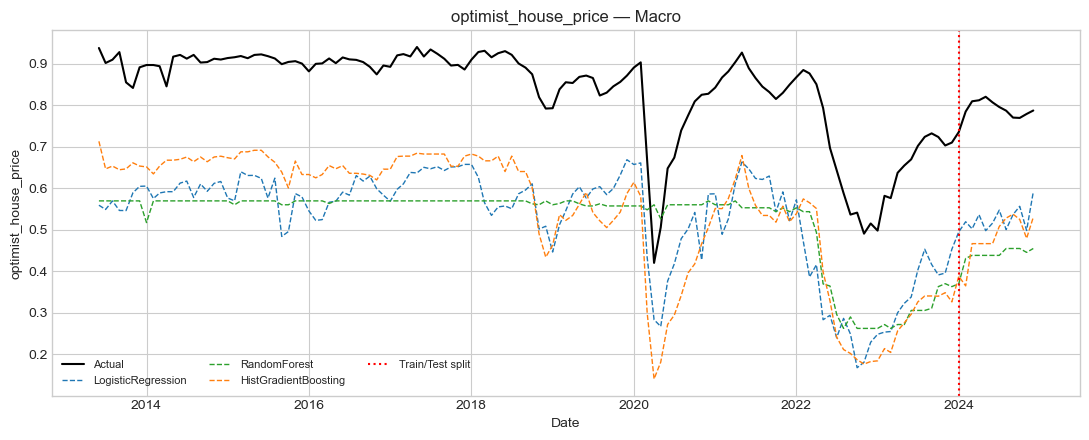

In [67]:
plot_predictions(res, train, test, target, num, cat, "Macro", split_date="2024-01-01")

With macro features only, the models follow the main movements in house price optimism, including the COVID‑19 drop and subsequent recovery, but consistently predict much lower optimism than observed. This reflects that most respondents are optimistic while macro variables provide little information to separate optimists from pessimists. With class_weight='balanced', always predicting the optimistic majority is penalised, pushing the models toward too much predicted pessimism. In the test period (2024), they continue to track the broad downturn and stabilisation, yet remain well below the actual series.

### 6.2 - Add SCE Features


── optimist_unrate (Macro + SCE) ──
  LogisticRegression C=0.0001                             CV ROC-AUC=0.5417
  RandomForest max_depth=2                          CV ROC-AUC=0.5409
  HistGradientBoosting max_depth=5                          CV ROC-AUC=0.5432


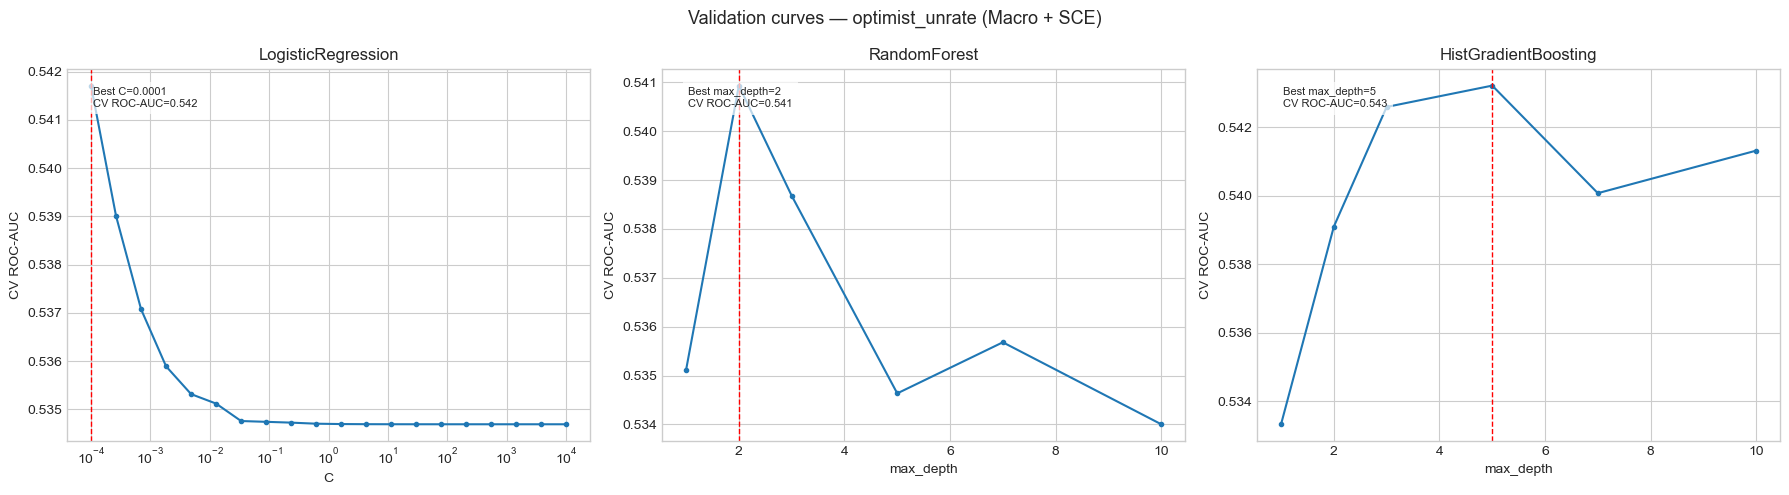

In [68]:
# Initialize features for the "Macro + SCE" feature set
num, cat = FEATURE_SETS_OPT["Macro + SCE"]

# Unemployment rate optimists target
target = "optimist_unrate"

# Run CV, store results and compute test metrics for the "Macro + SCE" feature set
res = run_cv_for_target(train, target, num, cat, "Macro + SCE", PART_6=True)
clf_test_metrics.append(test_metrics_clf(res, test, target, num, cat, "Macro + SCE"))
clf_train_metrics.append(test_metrics_clf(res, train, target, num, cat, "Macro + SCE"))

Adding SCE variables provides only a marginal improvement: CV ROC‑AUC increases from about 0.53 to 0.54 for all three models. The validation curves look very similar to the macro‑only case, with LogisticRegression and RandomForest selecting the same optimal C and max_depth as before, while HistGradientBoosting now prefers a slightly deeper tree (max_depth = 5). Overall, the gains from adding SCE variables are statistically small and leave predictive performance only slightly above a random classifier.

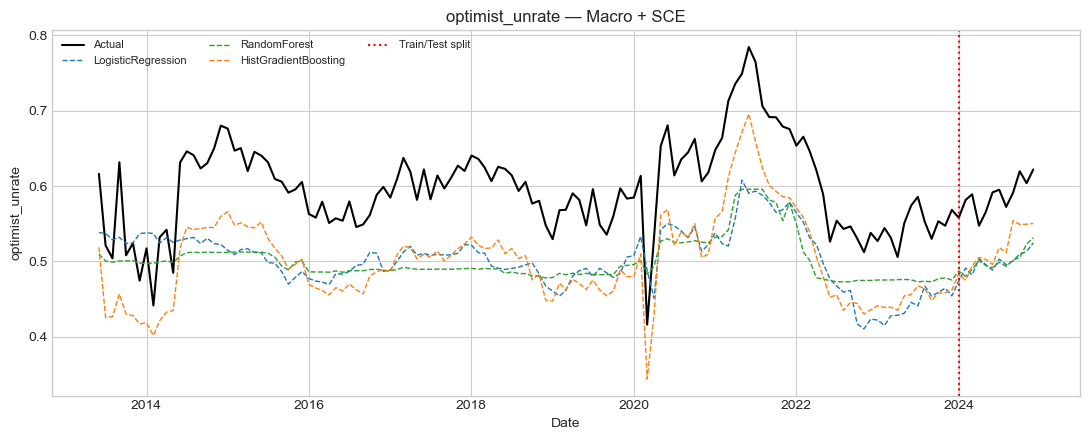

In [69]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE", split_date="2024-01-01")

With SCE variables, the models become slightly more responsive and follow the post‑2020 recovery somewhat better than in the macro‑only case, but a large level gap remains throughout. This is consistent with only a modest increase in ROC‑AUC and the use of class_weight='balanced'. In the test period (2024), the predictions do move up with the actual series, yet they continue to underpredict unemployment optimism.


── optimist_stocks (Macro + SCE) ──
  LogisticRegression C=0.0001                             CV ROC-AUC=0.5990
  RandomForest max_depth=1                          CV ROC-AUC=0.5763
  HistGradientBoosting max_depth=1                          CV ROC-AUC=0.5611


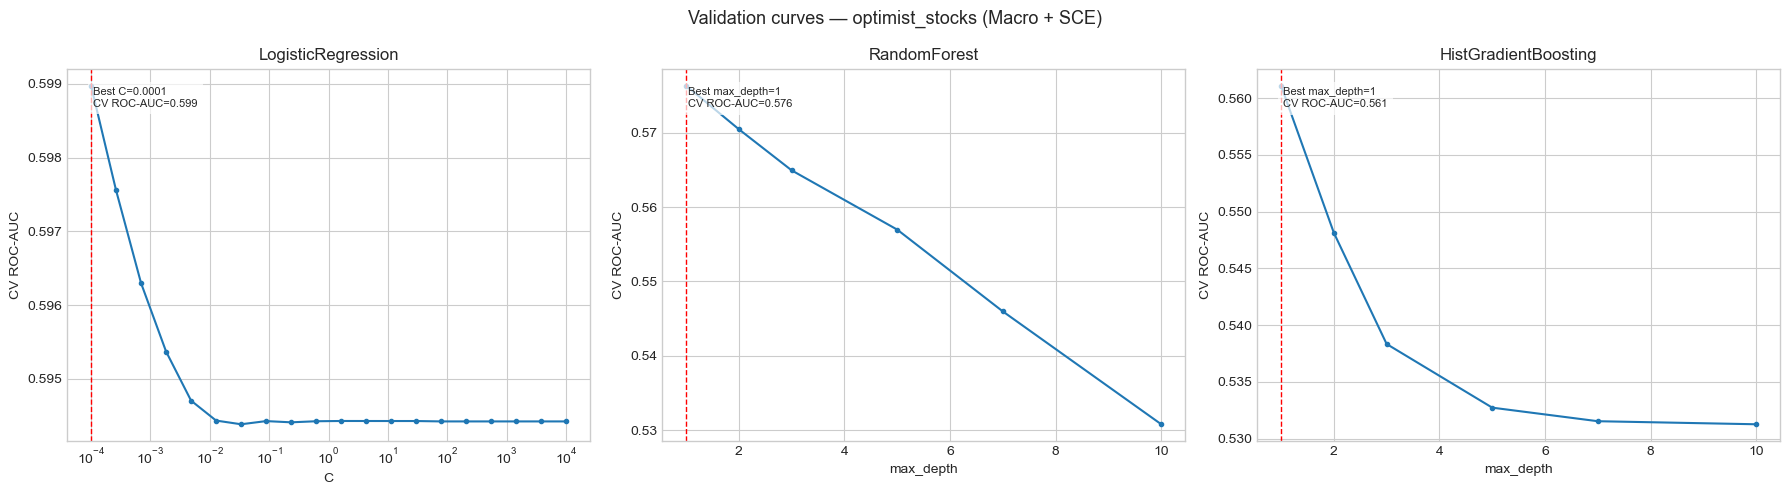

In [70]:
# Stock market optimists target
target = "optimist_stocks"

# Run CV, store results and compute test metrics for the "Macro + SCE" feature set
res = run_cv_for_target(train, target, num, cat, "Macro + SCE", PART_6=True)
clf_test_metrics.append(test_metrics_clf(res, test, target, num, cat, "Macro + SCE"))
clf_train_metrics.append(test_metrics_clf(res, train, target, num, cat, "Macro + SCE"))

CV ROC-AUC jumps from below 0.48 for all models to above 0.56, which is a meaningful improvement, but still modest in absolute terms. The LogisticRegression validation curve shows a clear peak at C ≈ 0.001, and both tree models prefer shallow depth 1. This mirrors the finding where demographic variables were the strongest predictors of stock market optimism.

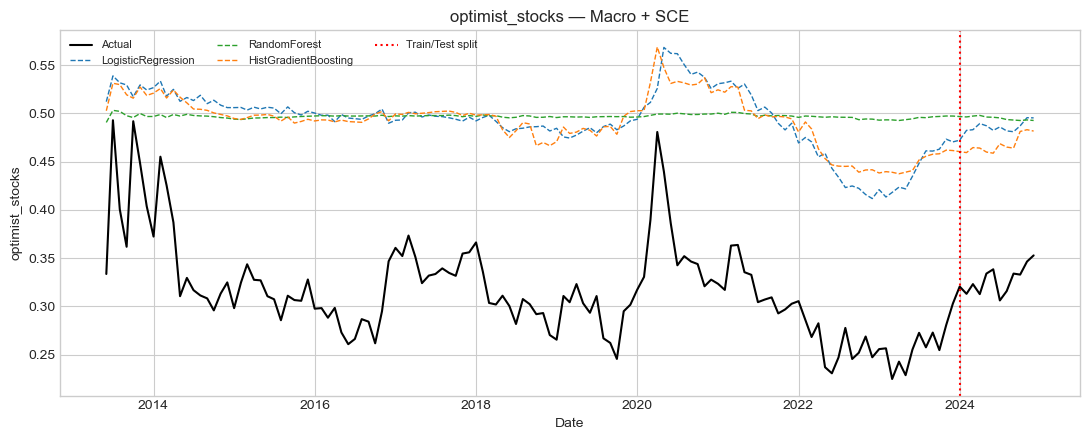

In [71]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE", split_date="2024-01-01")

Compared with the macro‑only case, where RandomForest visually captured most of the variation in stock market optimism, adding SCE variables changes the picture. LogisticRegression and HistGradientBoosting now display clearer cyclical movements and react more visibly to the COVID‑19 shock and subsequent recovery, while RandomForest stays almost flat around 50%. In the test period (2024), the actual series turns up from low levels, whereas all model‑based predictions remain clustered around 50%. This level gap is consistent with weak predictive signal and the use of class_weight='balanced', which keeps predicted probabilities concentrated near one half.


── optimist_house_price (Macro + SCE) ──
  LogisticRegression C=0.0001                             CV ROC-AUC=0.3099
  RandomForest max_depth=1                          CV ROC-AUC=0.2980
  HistGradientBoosting max_depth=2                          CV ROC-AUC=0.1897


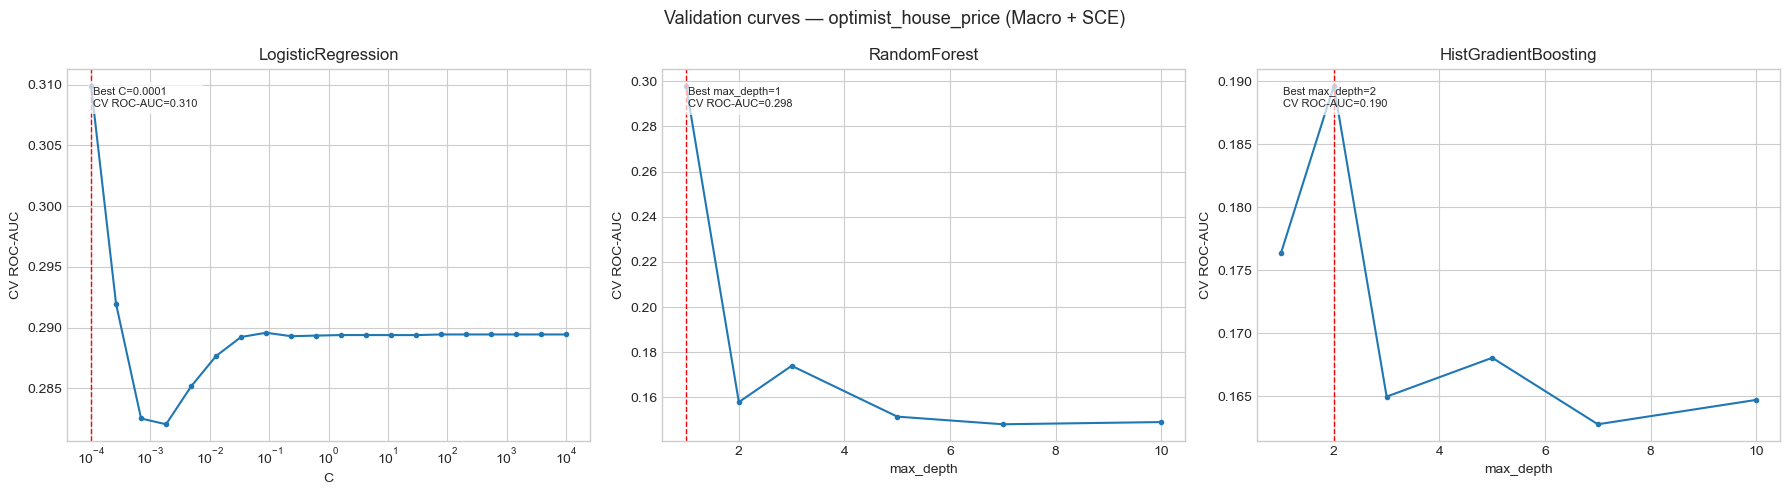

In [72]:
# House price optimists target
target = "optimist_house_price"

# Run CV, store results and compute test metrics for the "Macro + SCE" feature set
res = run_cv_for_target(train, target, num, cat, "Macro + SCE", PART_6=True)
clf_test_metrics.append(test_metrics_clf(res, test, target, num, cat, "Macro + SCE"))
clf_train_metrics.append(test_metrics_clf(res, train, target, num, cat, "Macro + SCE"))

Adding SCE variables does essentially nothing for the house price optimism indicator: CV ROC‑AUC stays at very low levels for all models and is almost unchanged compared with the macro‑only case. The optimal hyperparameters (C and max_depth) are also the same as before, which is consistent with the near‑zero correlations between SCE covariates and this target.

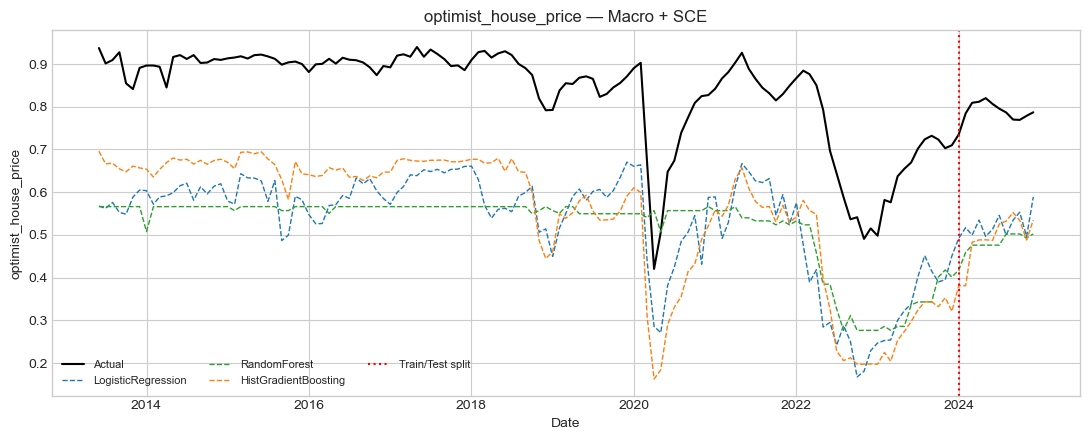

In [73]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE", split_date="2024-01-01")

With SCE variables, the predicted series look very similar to the macro‑only case. All models track some of the short‑run movements in house price optimism, including the COVID‑19 drop and the subsequent recovery, but they do so at a much lower level than the actual series. The fundamental difficulty remains the same: with the vast majority of respondents being house price optimists and no strong predictors available, the models have very limited ability to discriminate between optimists and pessimists. In the test period (2024), the actual series declines from high optimism and then stabilises, and while the models follow this pattern to some extent, their predicted optimism rates remain far below the observed levels.

**An overall comment on the effect of class_weight='balanced' on the prediction results**

Since class_weight='balanced' upweights the minority class during training, the models are encouraged to predict class 0 more frequently than the raw class frequency would suggest. This explains why the predicted fractions are systematically lower than the actual fractions — particularly for optimist_house_price where the majority-class share is 83.5%. This is a deliberate tradeoff: without class_weight='balanced', models predict class 1 for nearly all observations, which is uninformative despite yielding high accuracy.

In [74]:
# Display performance metrics for the classification models on the training sample
train_df_opt = pd.concat(clf_train_metrics, ignore_index=True)
train_pivot_opt = train_df_opt.pivot_table(
    index=['target', 'feature_set'],
    columns='model',
    values=['Accuracy', 'F1', 'ROC-AUC', 'Precision', 'Recall']
).round(4).T

display(train_pivot_opt)

target                         optimist_house_price              \
feature_set                                   Macro Macro + SCE   
          model                                                   
Accuracy  HistGradientBoosting               0.7518      0.7327   
          LogisticRegression                 0.7336      0.7265   
          RandomForest                       0.7866      0.7866   
F1        HistGradientBoosting               0.8432      0.8272   
          LogisticRegression                 0.8298      0.8236   
          RandomForest                       0.8722      0.8722   
Precision HistGradientBoosting               0.8926      0.8984   
          LogisticRegression                 0.8892      0.8923   
          RandomForest                       0.8725      0.8725   
ROC-AUC   HistGradientBoosting               0.7013      0.7228   
          LogisticRegression                 0.6728      0.6930   
          RandomForest                       0.6667      0.6743   
Recall    HistGradientBoosting               0.7989      0.7665   
          LogisticRegression                 0.7779      0.7648   
          RandomForest                       0.8718      0.8718   

target                         optimist_stocks             optimist_unrate  \
feature_set                              Macro Macro + SCE           Macro   
          model                                                              
Accuracy  HistGradientBoosting          0.5255      0.5974          0.5444   
          LogisticRegression            0.5004      0.5912          0.5358   
          RandomForest                  0.5349      0.5778          0.5027   
F1        HistGradientBoosting          0.4160      0.4867          0.5935   
          LogisticRegression            0.4258      0.4853          0.5770   
          RandomForest                  0.4147      0.4859          0.4660   
Precision HistGradientBoosting          0.3349      0.4006          0.6424   
          LogisticRegression            0.3295      0.3963          0.6405   
          RandomForest                  0.3385      0.3886          0.6612   
ROC-AUC   HistGradientBoosting          0.5468      0.6387          0.5595   
          LogisticRegression            0.5397      0.6344          0.5527   
          RandomForest                  0.5515      0.6282          0.5569   
Recall    HistGradientBoosting          0.5490      0.6200          0.5516   
          LogisticRegression            0.6018      0.6258          0.5249   
          RandomForest                  0.5352      0.6481          0.3598   

target                                      
feature_set                    Macro + SCE  
          model                             
Accuracy  HistGradientBoosting      0.6025  
          LogisticRegression        0.5429  
          RandomForest              0.5393  
F1        HistGradientBoosting      0.6533  
          LogisticRegression        0.5840  
          RandomForest              0.5624  
Precision HistGradientBoosting      0.6891  
          LogisticRegression        0.6472  
          RandomForest              0.6583  
ROC-AUC   HistGradientBoosting      0.6417  
          LogisticRegression        0.5682  
          RandomForest              0.5791  
Recall    HistGradientBoosting      0.6210  
          LogisticRegression        0.5320  
          RandomForest              0.4909

On the training sample, performance is modest across all targets and feature sets. For optimist_unrate, ROC‑AUC is about 0.55–0.64 with Macro only and improves slightly to 0.57–0.64 with Macro + SCE, with HistGradientBoosting highest in both cases. For optimist_stocks, ROC‑AUC rises from roughly 0.54–0.55 (Macro) to 0.62–0.64 (Macro + SCE), which is the largest gain across the three targets and confirms that SCE variables add useful signal here. For optimist_house_price, ROC‑AUC around 0.67–0.70 is similar in both feature sets; this relatively high training performance largely reflects the strong majority‑class pattern rather than genuinely accurate discrimination. The imbalance shows up in the metrics, with Precision higher than Recall for optimist_house_price, which reflects that pessimists are hard to detect. For the other two targets, Recall tends to exceed Precision, which indicates more false positives when identifying optimists.

In [75]:
# Display performance metrics for classification models on the test sample
results_df_opt = pd.concat(clf_test_metrics, ignore_index=True)
results_pivot_opt = results_df_opt.pivot_table(
    index=['target', 'feature_set'],
    columns='model',
    values=['Accuracy', 'F1', 'ROC-AUC', 'Precision', 'Recall']
).round(4).T

display(results_pivot_opt)

target                         optimist_house_price              \
feature_set                                   Macro Macro + SCE   
          model                                                   
Accuracy  HistGradientBoosting               0.4411      0.4558   
          LogisticRegression                 0.6499      0.5908   
          RandomForest                       0.2121      0.3909   
F1        HistGradientBoosting               0.5320      0.5455   
          LogisticRegression                 0.7725      0.7147   
          RandomForest                       0.0000      0.4509   
Precision HistGradientBoosting               0.7817      0.7976   
          LogisticRegression                 0.7914      0.7929   
          RandomForest                       0.0000      0.7780   
ROC-AUC   HistGradientBoosting               0.4974      0.5227   
          LogisticRegression                 0.5033      0.5147   
          RandomForest                       0.5005      0.5039   
Recall    HistGradientBoosting               0.4032      0.4145   
          LogisticRegression                 0.7546      0.6506   
          RandomForest                       0.0000      0.3175   

target                         optimist_stocks             optimist_unrate  \
feature_set                              Macro Macro + SCE           Macro   
          model                                                              
Accuracy  HistGradientBoosting          0.6009      0.6587          0.5608   
          LogisticRegression            0.5401      0.6294          0.4916   
          RandomForest                  0.6009      0.6271          0.4826   
F1        HistGradientBoosting          0.2844      0.5305          0.6881   
          LogisticRegression            0.3671      0.5354          0.4840   
          RandomForest                  0.2844      0.5475          0.4248   
Precision HistGradientBoosting          0.3437      0.4821          0.5890   
          LogisticRegression            0.3337      0.4536          0.5966   
          RandomForest                  0.3437      0.4538          0.6088   
ROC-AUC   HistGradientBoosting          0.5073      0.6902          0.5146   
          LogisticRegression            0.5074      0.6862          0.5129   
          RandomForest                  0.5089      0.6833          0.5148   
Recall    HistGradientBoosting          0.2426      0.5899          0.8272   
          LogisticRegression            0.4080      0.6530          0.4072   
          RandomForest                  0.2426      0.6900          0.3262   

target                                      
feature_set                    Macro + SCE  
          model                             
Accuracy  HistGradientBoosting      0.5816  
          LogisticRegression        0.5758  
          RandomForest              0.5618  
F1        HistGradientBoosting      0.6410  
          LogisticRegression        0.5912  
          RandomForest              0.5816  
Precision HistGradientBoosting      0.6443  
          LogisticRegression        0.6785  
          RandomForest              0.6596  
ROC-AUC   HistGradientBoosting      0.6084  
          LogisticRegression        0.6171  
          RandomForest              0.5913  
Recall    HistGradientBoosting      0.6377  
          LogisticRegression        0.5238  
          RandomForest              0.5201

On the test sample, optimist_stocks shows the largest gain from adding SCE variables. ROC‑AUC rises from about 0.51 with Macro only to around 0.68–0.69 with Macro + SCE, with all three models performing similarly. For optimist_unrate, ROC‑AUC improves from roughly 0.51 to about 0.60–0.62 when SCE variables are added. For optimist_house_price, ROC‑AUC stays close to 0.50–0.52 in both feature sets, confirming that neither macro nor demographic variables can meaningfully discriminate between house price optimists and pessimists. The gap between training and test ROC‑AUC is largest for this target, suggesting that the relatively high training performance mainly reflects fitting the majority‑class pattern rather than genuine predictive power. Overall, Macro + SCE consistently outperforms Macro only, and optimist_stocks is clearly the most predictable target.

## Part 7 - Conclusion

The results from Parts 5 and 6 are summarised and compared across models and feature sets, using RMSE and R² for the continuous expectations variables and ROC-AUC, Accuracy, F1, Precision and Recall for the binary optimism indicators.

In [76]:
# Part 5 results - All models and feature sets
display(results_pivot_exp)

target          house_price_change                infl_1y             \
feature_set            Macro + SCE Macro only Macro + SCE Macro only   
     model                                                             
R2   ElasticNet             0.0432    -0.0078      0.0497    -0.0053   
     Lasso                  0.0444    -0.0025      0.0497    -0.0053   
     OLS                    0.0432    -0.0077      0.0501    -0.0053   
     Ridge                  0.0431    -0.0079      0.0496    -0.0056   
     Tree                  -0.0142    -0.0014      0.0407    -0.0003   
RMSE ElasticNet             8.2553     8.4728      8.9990     9.2557   
     Lasso                  8.2504     8.4505      8.9990     9.2557   
     OLS                    8.2555     8.4721      8.9970     9.2558   
     Ridge                  8.2558     8.4730      8.9994     9.2571   
     Tree                   8.4996     8.4457      9.0415     9.2328   

target          prob_stocks_up            prob_unrate_up             
feature_set        Macro + SCE Macro only    Macro + SCE Macro only  
     model                                                           
R2   ElasticNet         0.1185    -0.0024         0.0297    -0.0008  
     Lasso              0.1185    -0.0021         0.0241     0.0003  
     OLS                0.1187    -0.0042         0.0353    -0.0035  
     Ridge              0.1181    -0.0027         0.0247    -0.0014  
     Tree               0.1148    -0.0210         0.0266    -0.0033  
RMSE ElasticNet        21.5527    22.9826        21.9871    22.3307  
     Lasso             21.5527    22.9795        22.0508    22.3183  
     OLS               21.5498    23.0038        21.9240    22.3601  
     Ridge             21.5572    22.9864        22.0444    22.3365  
     Tree              21.5972    23.1955        22.0226    22.3584

Across all four continuous expectation targets, the Macro+SCE feature set dominates Macro-only on both R² and RMSE. With macro/finance variables alone, R² is at or below zero for every target — the models cannot beat the unconditional mean on the 2024 test sample. Adding SCE variables lifts R² to roughly 0.04–0.05 for infl_1y, house_price_change, and prob_unrate_up, and to 0.119 for prob_stocks_up. Within each target, the four linear models (OLS, Ridge, Lasso, ElasticNet) produce near-identical scores - differences at the third decimal - while the Decision Tree is consistently the weakest and produces the only negative Macro+SCE R² (−0.014 for house_price_change). This pattern - a large gap between feature sets but a small gap between linear models - is consistent with a setting where regularisation has little to do because the training sample is large relative to the feature count, and where the signal comes from a few individual-level demographics rather than from a fine-tuned hyperparameter.

In [77]:
# Part 5 - Best models summary
display(summary_df_exp)

,target,best_R2_model,best_R2,best_R2_feature_set,best_RMSE_model,best_RMSE,best_RMSE_feature_set
0,infl_1y,OLS,0.050128,Macro + SCE,OLS,8.997028,Macro + SCE
1,house_price_change,Lasso,0.044370,Macro + SCE,Lasso,8.250429,Macro + SCE
2,prob_unrate_up,OLS,0.035290,Macro + SCE,OLS,21.923992,Macro + SCE
3,prob_stocks_up,OLS,0.118698,Macro + SCE,OLS,21.549830,Macro + SCE


The best feature set is Macro+SCE for every target, and OLS is the best (or tied-best) model for three of the four targets - Lasso is narrowly best for house_price_change (R² 0.0444 vs 0.0432 for OLS). prob_stocks_up is the most predictable target at R² ≈ 0.12, driven by financial literacy, gender, education, and income rank; the other three targets sit in the 0.03–0.05 range. Even the best models leave the large majority of individual-level variation unexplained, which is expected given that household-level expectations are inherently heterogeneous and only modestly related to aggregate macro conditions.

In [78]:
# Part 6 training results - All models and feature sets
display(train_pivot_opt)

target                         optimist_house_price              \
feature_set                                   Macro Macro + SCE   
          model                                                   
Accuracy  HistGradientBoosting               0.7518      0.7327   
          LogisticRegression                 0.7336      0.7265   
          RandomForest                       0.7866      0.7866   
F1        HistGradientBoosting               0.8432      0.8272   
          LogisticRegression                 0.8298      0.8236   
          RandomForest                       0.8722      0.8722   
Precision HistGradientBoosting               0.8926      0.8984   
          LogisticRegression                 0.8892      0.8923   
          RandomForest                       0.8725      0.8725   
ROC-AUC   HistGradientBoosting               0.7013      0.7228   
          LogisticRegression                 0.6728      0.6930   
          RandomForest                       0.6667      0.6743   
Recall    HistGradientBoosting               0.7989      0.7665   
          LogisticRegression                 0.7779      0.7648   
          RandomForest                       0.8718      0.8718   

target                         optimist_stocks             optimist_unrate  \
feature_set                              Macro Macro + SCE           Macro   
          model                                                              
Accuracy  HistGradientBoosting          0.5255      0.5974          0.5444   
          LogisticRegression            0.5004      0.5912          0.5358   
          RandomForest                  0.5349      0.5778          0.5027   
F1        HistGradientBoosting          0.4160      0.4867          0.5935   
          LogisticRegression            0.4258      0.4853          0.5770   
          RandomForest                  0.4147      0.4859          0.4660   
Precision HistGradientBoosting          0.3349      0.4006          0.6424   
          LogisticRegression            0.3295      0.3963          0.6405   
          RandomForest                  0.3385      0.3886          0.6612   
ROC-AUC   HistGradientBoosting          0.5468      0.6387          0.5595   
          LogisticRegression            0.5397      0.6344          0.5527   
          RandomForest                  0.5515      0.6282          0.5569   
Recall    HistGradientBoosting          0.5490      0.6200          0.5516   
          LogisticRegression            0.6018      0.6258          0.5249   
          RandomForest                  0.5352      0.6481          0.3598   

target                                      
feature_set                    Macro + SCE  
          model                             
Accuracy  HistGradientBoosting      0.6025  
          LogisticRegression        0.5429  
          RandomForest              0.5393  
F1        HistGradientBoosting      0.6533  
          LogisticRegression        0.5840  
          RandomForest              0.5624  
Precision HistGradientBoosting      0.6891  
          LogisticRegression        0.6472  
          RandomForest              0.6583  
ROC-AUC   HistGradientBoosting      0.6417  
          LogisticRegression        0.5682  
          RandomForest              0.5791  
Recall    HistGradientBoosting      0.6210  
          LogisticRegression        0.5320  
          RandomForest              0.4909

The training-sample table reports in-sample fit and should be read as an upper bound on what the models have learned, not as a measure of generalisation. The high accuracy (0.73–0.79) and F1 (0.82–0.87) for optimist_house_price are driven by the ~85% positive-class base rate rather than by discriminatory power: this is visible in the ROC-AUC column, where the same models sit at 0.67–0.72. Across all three targets and all three classifiers, adding SCE lifts in-sample ROC-AUC by roughly 0.04–0.09 points. HistGradientBoosting and RandomForest reach the highest training scores in almost every cell - partly because they have the capacity to overfit individual-level noise - so the meaningful comparison across models and feature sets is deferred to the test-sample table.

In [79]:
# Part 6 test results - All models and feature sets
display(results_pivot_opt)

target                         optimist_house_price              \
feature_set                                   Macro Macro + SCE   
          model                                                   
Accuracy  HistGradientBoosting               0.4411      0.4558   
          LogisticRegression                 0.6499      0.5908   
          RandomForest                       0.2121      0.3909   
F1        HistGradientBoosting               0.5320      0.5455   
          LogisticRegression                 0.7725      0.7147   
          RandomForest                       0.0000      0.4509   
Precision HistGradientBoosting               0.7817      0.7976   
          LogisticRegression                 0.7914      0.7929   
          RandomForest                       0.0000      0.7780   
ROC-AUC   HistGradientBoosting               0.4974      0.5227   
          LogisticRegression                 0.5033      0.5147   
          RandomForest                       0.5005      0.5039   
Recall    HistGradientBoosting               0.4032      0.4145   
          LogisticRegression                 0.7546      0.6506   
          RandomForest                       0.0000      0.3175   

target                         optimist_stocks             optimist_unrate  \
feature_set                              Macro Macro + SCE           Macro   
          model                                                              
Accuracy  HistGradientBoosting          0.6009      0.6587          0.5608   
          LogisticRegression            0.5401      0.6294          0.4916   
          RandomForest                  0.6009      0.6271          0.4826   
F1        HistGradientBoosting          0.2844      0.5305          0.6881   
          LogisticRegression            0.3671      0.5354          0.4840   
          RandomForest                  0.2844      0.5475          0.4248   
Precision HistGradientBoosting          0.3437      0.4821          0.5890   
          LogisticRegression            0.3337      0.4536          0.5966   
          RandomForest                  0.3437      0.4538          0.6088   
ROC-AUC   HistGradientBoosting          0.5073      0.6902          0.5146   
          LogisticRegression            0.5074      0.6862          0.5129   
          RandomForest                  0.5089      0.6833          0.5148   
Recall    HistGradientBoosting          0.2426      0.5899          0.8272   
          LogisticRegression            0.4080      0.6530          0.4072   
          RandomForest                  0.2426      0.6900          0.3262   

target                                      
feature_set                    Macro + SCE  
          model                             
Accuracy  HistGradientBoosting      0.5816  
          LogisticRegression        0.5758  
          RandomForest              0.5618  
F1        HistGradientBoosting      0.6410  
          LogisticRegression        0.5912  
          RandomForest              0.5816  
Precision HistGradientBoosting      0.6443  
          LogisticRegression        0.6785  
          RandomForest              0.6596  
ROC-AUC   HistGradientBoosting      0.6084  
          LogisticRegression        0.6171  
          RandomForest              0.5913  
Recall    HistGradientBoosting      0.6377  
          LogisticRegression        0.5238  
          RandomForest              0.5201

Out-of-sample on 2024, the picture differs sharply from the training view. For optimist_house_price, every model collapses to ROC-AUC ≈ 0.50 regardless of feature set - the probability rankings are no better than random, and RandomForest under Macro-only degenerates to predicting the negative class for every row (F1 = 0, accuracy = 0.21). This is consistent with the idea that the training-period signal for house-price optimism is driven by trending macro levels, whose associations do not extrapolate well to 2024. For optimist_stocks, Macro-only remains near-random (ROC-AUC ≈ 0.51), while Macro+SCE lifts ROC-AUC to ~0.69 across all three classifiers - the cleanest evidence in the exercise that SCE variables carry generalisable signal. For optimist_unrate, Macro-only is again near random and Macro+SCE produces a moderate lift to ROC-AUC ≈ 0.59–0.62. Because optimist_house_price has a heavily skewed class distribution, raw accuracy is misleading for that target - ROC-AUC and F1 give the more honest picture, and by those metrics the macro features provide essentially no OOS traction.

### Final Comment

Across both the regression exercise in Part 5 and the classification exercise in Part 6, a consistent pattern emerges. First, adding stable individual-level SCE characteristics - financial literacy, gender, education, income rank, and age - improves predictive performance for every target and under every model we estimated. Macro/finance variables on their own produce near-zero or negative R² in Part 5 and near-random ROC-AUC on the 2024 test set in Part 6. 

Second, within each feature set the choice of model matters much less than the choice of feature set: the four linear regressors in Part 5 produce nearly identical scores, and the three classifiers in Part 6 are generally within 0.02 ROC-AUC of one another once the feature set is fixed. Where a model does stand out, it tends to be OLS (Part 5) or HistGradientBoosting (Part 6, training), with Lasso narrowly winning for house_price_change in Part 5.

Third, predictability is highly target-dependent. Stock-market expectations are the easiest to predict: Part 5 test R² reaches 0.12 for prob_stocks_up and Part 6 test ROC-AUC reaches 0.69 for optimist_stocks under Macro+SCE. Unemployment expectations are intermediate (R² 0.035, ROC-AUC 0.60). House-price expectations are the hardest out-of-sample case: adding SCE lifts Part 5 R² from negative to 0.044, but in Part 6 every classifier produces test ROC-AUC ≈ 0.50 for optimist_house_price. The deterioration relative to the training sample is consistent with macro-based fit for house-price optimism relying heavily on trending level series (CPI, house-price index, real GDP) whose training-period relationships do not hold on the 2024 window.

Taken together, the best-performing configuration is the Macro+SCE feature set paired with a linear model (OLS or Lasso) for the continuous targets and the same feature set with any of the three classifiers - with a small preference for Logistic Regression, given its flat hyperparameter surface and almost identical test ROC-AUC to the tree-based methods - for the optimism indicators. Absolute performance remains modest in all cases, which is expected: aggregate macroeconomic conditions and stable demographics are, at best, weak predictors of heterogeneous individual-level expectations, and the most honest takeaway from the exercise is not a specific R² number but the relative finding that demographics consistently matter more than macro conditions and that stock-market expectations are the most predictable of the four.

In [80]:
# Checking class balance and prediction shares - Showing how balanced class weight works
for t in OPTIMISM_COLS:
    p = train[t].mean()
    print(f"{t:22s}  majority-class share = {max(p, 1-p):.3f}")

# Then, after a run:
for name, mr in res.items():
    preds = mr["pipeline"].predict(train[num + cat])
    print(f"{name:22s}  fraction predicted as 1 = {preds.mean():.3f}")

optimist_unrate         majority-class share = 0.603
optimist_stocks         majority-class share = 0.692
optimist_house_price    majority-class share = 0.835
LogisticRegression      fraction predicted as 1 = 0.716
RandomForest            fraction predicted as 1 = 0.834
HistGradientBoosting    fraction predicted as 1 = 0.712


**A final note on the effect of balanced class weight**: 

In preliminary testing, all models consistently predicted basically every single observation as optimists for all targets. To see if we could get a more interesting and interpretable result, we introduced a class weight to penalize wrongful predictions of category 1. This draws the predictions closer to the threshold of 50% and forces the models to predict a higher share of pessimists. As we can see from the short output above, this has worked - fractions predicted as 1 are drawn closer to the actual share instead of only predicting 1's. 